#### Imports / configuration loading

In [40]:
# Reload imports if needed
import source
import importlib
importlib.reload(source.results_analysis)
importlib.reload(source.train_predictive_models)
importlib.reload(source.predictive_models)
importlib.reload(source.exploration)
importlib.reload(source.map_loader)


<module 'source.map_loader' from '/home/tiago/projects/predictive_model_latent_space/source/map_loader.py'>

In [41]:

from source import agents, exploration, predictive_models
from source.map_loader import Env
from source.train_predictive_models import process_input, runSGD, one_hot_encode
from source.results_analysis import metrics_predict_map,print_metrics,latent_space_PCA
from pathlib import Path
import source.results_analysis as results_analysis
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import json
import os
import textwrap
from tqdm import tqdm
import pandas as pd
import seaborn as sns

map_files = ["8x8_colors_noobj.txt","20x20_colors.txt", "50x50_colors.txt"] 
map_labels = ["8x8_colors","20x20_colors", "50x50_colors"] 
dims = [[8,8],[20,20],[50,50]]
map_types = ["color","color","color"]
config_files = ["egocentric_empty_7x7view_rnn_separate_action.json"]
seeds = [77243, 798315, 101125]
n_action_seq = [1,2,4,8,16]
configs = []

for config in config_files:
    with open(f"configs/multiple_action_sequences/{config}", 'r') as file: 
       configs.append(json.load(file))

####  Data generation

In [3]:
loaded_data = [{k3: None for k3 in seeds} for i in range(len(map_files))] 
observation_spaces = {"egocentric": exploration.exploration_egocentric,"allocentric":exploration.exploration_allocentric}

config = configs[0]
observation_space = config["observation_space"]

data_keys = ['img_train', 'pos_train', 'dir_train', 'img_test', 'pos_test', 'dir_test']
for c in range(len(map_files)):
    with open(f"maps/{map_files[c]}", 'r') as file:
        map = [[int(x) for x in line.strip().split(" ")] for line in file ]
    if (map_types[c]=="color"):
        with open(f"maps/colors/{map_files[c]}", 'r') as file:
            color_map = [[int(x) for x in line.strip().split(" ")] for line in file ]
    else:
        color_map = None
    env = Env(map,dims[c],tuple(config['start_pos']),seed=config['env_seed'],render_mode="rgb_array",agent_view_size=config['egocentric_view_size'])
    env.reset(seed=env.env_seed)
    for seed in seeds:
        if observation_space == "egocentric":
            agent_type = ["random", [0.3333, 0.3333, 0.3334],seed]
        elif observation_space == "allocentric":
            agent_type = ["random", [0.25, 0.25, 0.25, 0.25], seed]

        outfolder = f"exploration_data/multiple_action_sequences/{map_labels[c]}"
        outdir = f"{outfolder}/{seed}_exploration_data.npz"
        Path(outfolder).mkdir(parents=True, exist_ok=True)
        print(f"Setting:{c}, {observation_space}, {seed}")
        try:
            with np.load(outdir) as data:
                loaded_data[c][seed] = [data[k] for k in data_keys]
                print ("Successfully loaded data!")
        except (FileNotFoundError, Exception):
            config['agent_type'][2] = seed
            env = Env(map,dims[c],tuple(config['start_pos']),seed=seed,render_mode="rgb_array",agent_view_size=config['egocentric_view_size'],colors=color_map)
            env.reset(seed=env.env_seed)
            loaded_data[c][seed] = observation_spaces[observation_space](
            env,
            agent_type=agent_type,
            n_steps_train=config['number_steps_train'],
            n_steps_test=config['number_steps_test'],
            n_restart_train=config['num_random_position_restarts_train'],
            n_restart_test=config['num_random_position_restarts_test'],
            rgb_rep=True)
            exploration_data = loaded_data[c][seed]
            np.savez_compressed(outdir, **dict(zip(data_keys, exploration_data)))
            print ("Exploration complete!")


Setting:0, egocentric, 77243
Successfully loaded data!
Setting:0, egocentric, 798315
Successfully loaded data!
Setting:0, egocentric, 101125
Successfully loaded data!
Setting:1, egocentric, 77243
Successfully loaded data!
Setting:1, egocentric, 798315
Successfully loaded data!
Setting:1, egocentric, 101125
Successfully loaded data!
Setting:2, egocentric, 77243
Successfully loaded data!
Setting:2, egocentric, 798315
Successfully loaded data!
Setting:2, egocentric, 101125
Successfully loaded data!


(np.int64(4), np.int64(1))


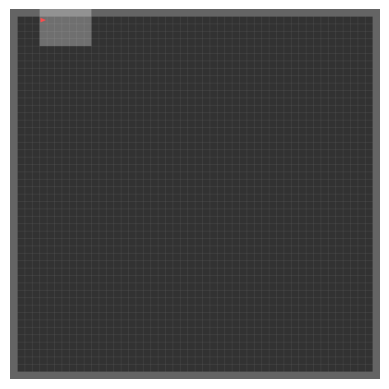

In [ ]:

# env.step(2)
# print(env.agent_pos)
# plt.imshow(env.render())
# plt.axis('off')
# plt.show()

#### Training predictive models

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 	 Loss train 	 Loss test
1/100	 2725.5637		 2780.7590
2/100	 2596.6704		 2644.7341
3/100	 2562.6990		 2615.9463
4/100	 2546.3374		 2604.6443
5/100	 2535.3574		 2597.4133
6/100	 2525.1951		 2591.4675
7/100	 2515.8994		 2585.6880
8/100	 2503.8186		 2575.2756
9/100	 2484.3030		 2558.3057
10/100	 2448.1230		 2518.1155
11/100	 2345.3848		 2412.6860
12/100	 2008.4559		 2054.7227
13/100	 1560.1870		 1563.9418
14/100	 1254.9667		 1239.4784
15/100	 1046.7517		 1024.6901
16/100	 849.5317		 830.1929
17/100	 679.6720		 659.4069
18/100	 549.0603		 524.9353
19/100	 453.4233		 428.1544
20/100	 390.3029		 362.2476
21/100	 346.8074		 317.4905
22/100	 320.3966		 290.4717
23/100	 300.3275		 269.6591
24/100	 287.9477		 256.5964
25/100	 274.2437		 243.3100
26/100	 269.7336		 239.3378
27/100	 251.2455		 220.6619
28/100	 243.8089		 213.3327
29/100	 237.3062		 207.0149
30/100	 231.0919		 200.5407
31/100	 227.1459		 197.0659
32/100	 221.9926		 191.7253
33/100	 216.7440		 186.4782
34/100	 212.8308		 182.5

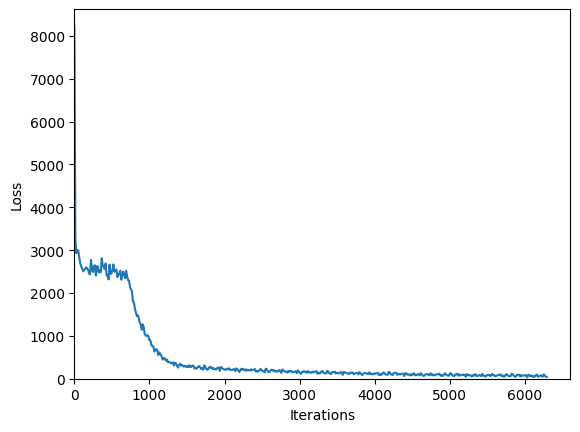

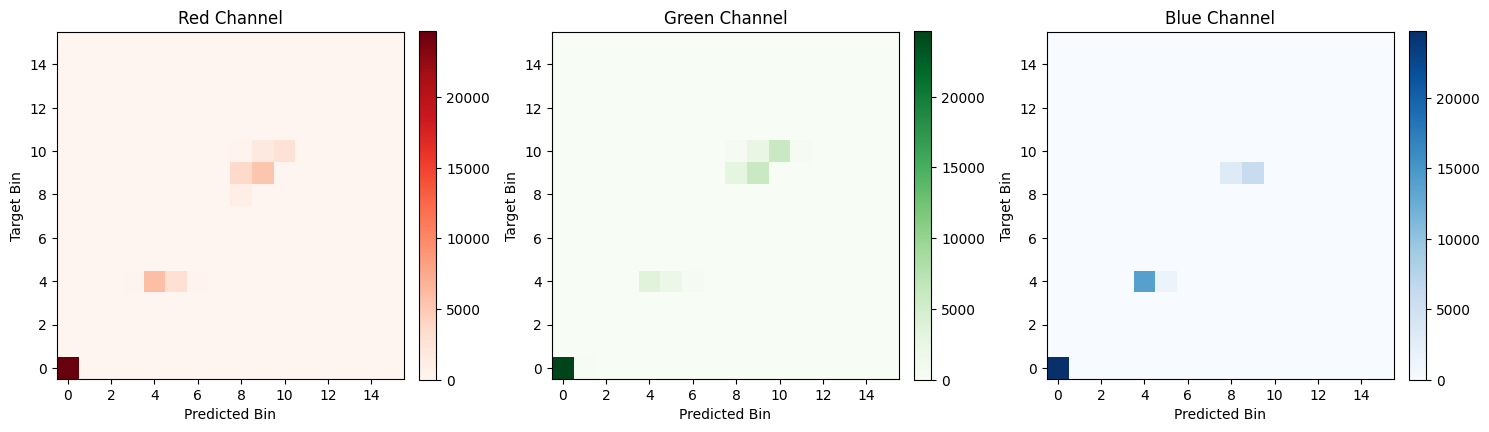

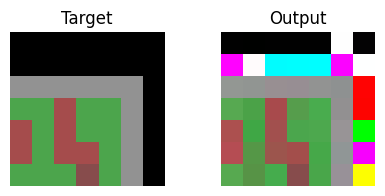

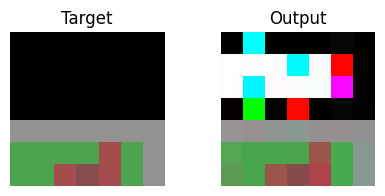

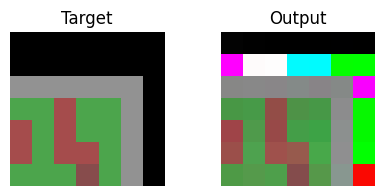

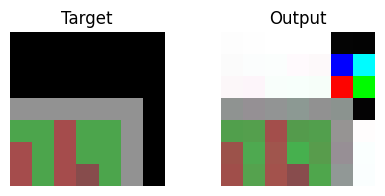

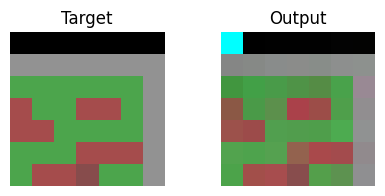

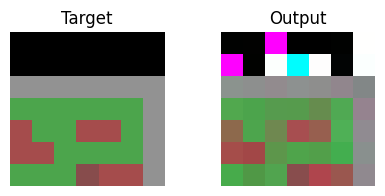

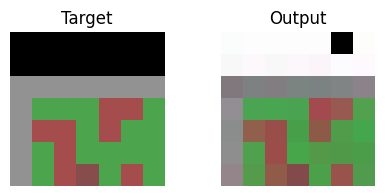

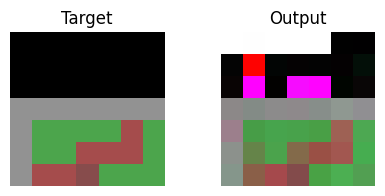

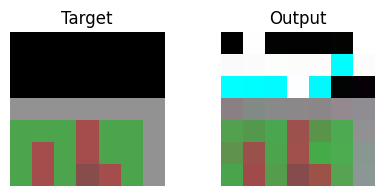

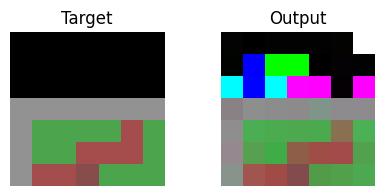

 33%|███▎      | 1/3 [00:42<01:25, 42.96s/it]

MSE Loss at the end of all the epochs, test: 35.516876220703125
Epoch 	 Loss train 	 Loss test
1/100	 2759.7024		 2721.4316
2/100	 2625.7837		 2602.3960
3/100	 2598.8784		 2584.1746
4/100	 2582.5845		 2574.3359
5/100	 2567.9902		 2563.1187
6/100	 2557.3813		 2554.9253
7/100	 2545.3931		 2545.8928
8/100	 2537.4368		 2541.0557
9/100	 2521.1233		 2529.2559
10/100	 2504.7368		 2515.2805
11/100	 2485.0669		 2497.3445
12/100	 2414.6028		 2430.2219
13/100	 2219.8826		 2230.5288
14/100	 1721.0730		 1694.0161
15/100	 1345.2079		 1323.7122
16/100	 1170.4240		 1148.0829
17/100	 1002.3402		 975.7708
18/100	 802.0716		 772.2365
19/100	 633.1146		 602.0074
20/100	 511.7448		 477.7498
21/100	 433.7637		 399.3179
22/100	 379.0296		 342.6169
23/100	 343.3049		 306.4485
24/100	 321.1095		 283.5350
25/100	 305.3196		 267.2972
26/100	 290.9456		 252.5918
27/100	 278.5596		 240.3984
28/100	 267.0356		 229.1283
29/100	 258.4832		 220.5631
30/100	 250.1798		 212.2729
31/100	 241.9354		 204.4270
32/100	 235.4

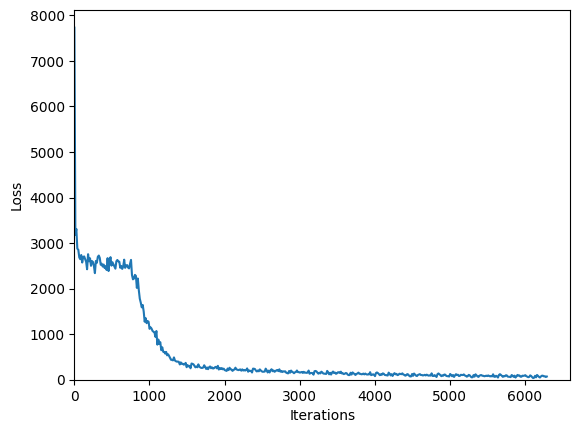

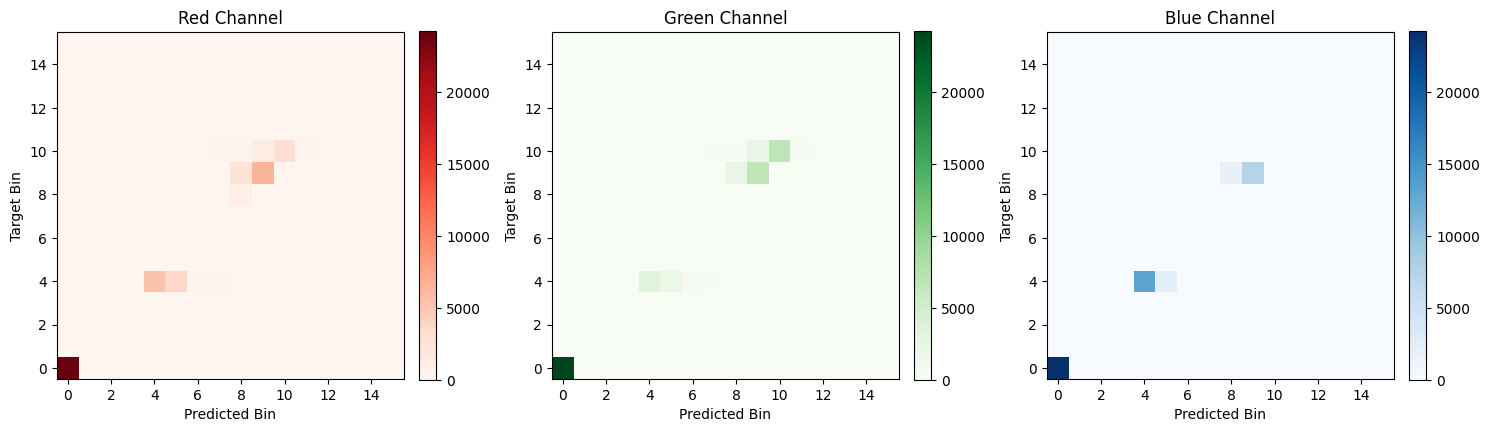

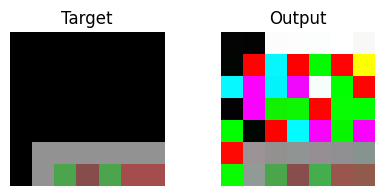

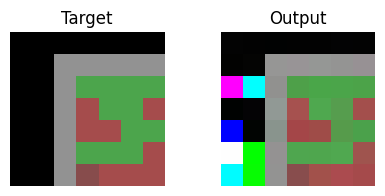

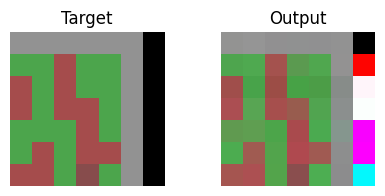

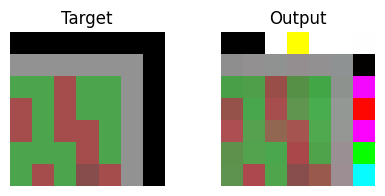

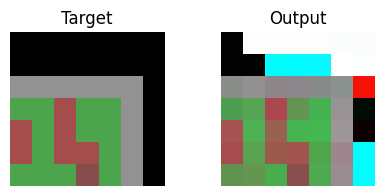

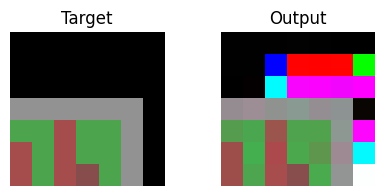

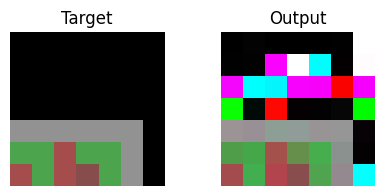

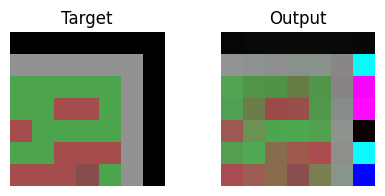

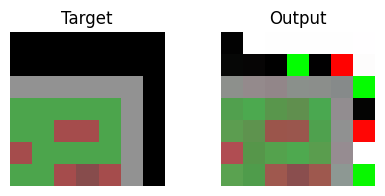

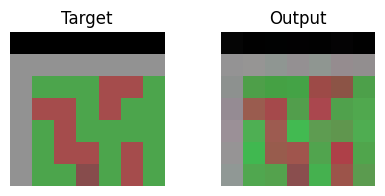

 67%|██████▋   | 2/3 [01:27<00:43, 43.96s/it]

MSE Loss at the end of all the epochs, test: 36.1452751159668
Epoch 	 Loss train 	 Loss test
1/100	 2712.6538		 2786.1560
2/100	 2608.0286		 2680.5627
3/100	 2584.5232		 2666.5449
4/100	 2574.6018		 2666.5049
5/100	 2565.9917		 2666.3391
6/100	 2561.0825		 2669.2480
7/100	 2553.3098		 2666.4084
8/100	 2541.9485		 2658.0916
9/100	 2531.7031		 2648.4556
10/100	 2499.7256		 2621.0552
11/100	 2414.9263		 2516.1526
12/100	 2181.0703		 2219.4150
13/100	 1664.8986		 1664.4122
14/100	 1319.7244		 1273.9030
15/100	 1093.4956		 1036.1835
16/100	 892.3136		 832.3091
17/100	 683.2610		 623.0063
18/100	 529.4838		 475.1916
19/100	 438.4482		 388.1364
20/100	 382.5067		 335.2331
21/100	 343.6376		 298.3731
22/100	 316.4406		 272.9955
23/100	 296.0283		 253.4959
24/100	 280.2217		 237.6722
25/100	 267.6922		 225.7097
26/100	 256.8492		 214.9781
27/100	 247.8038		 206.1754
28/100	 239.7554		 198.3845
29/100	 233.1531		 191.8103
30/100	 226.6738		 185.5254
31/100	 220.5745		 179.5763
32/100	 215.6365		

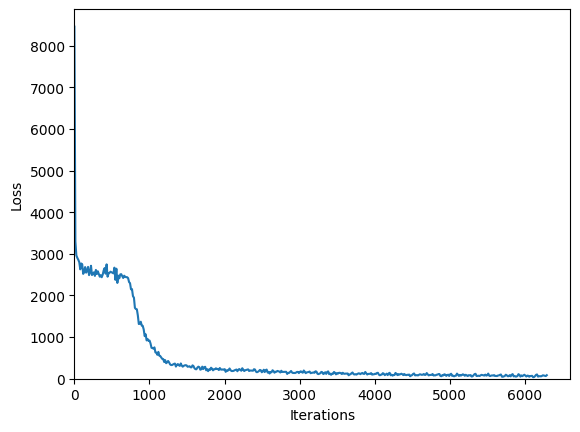

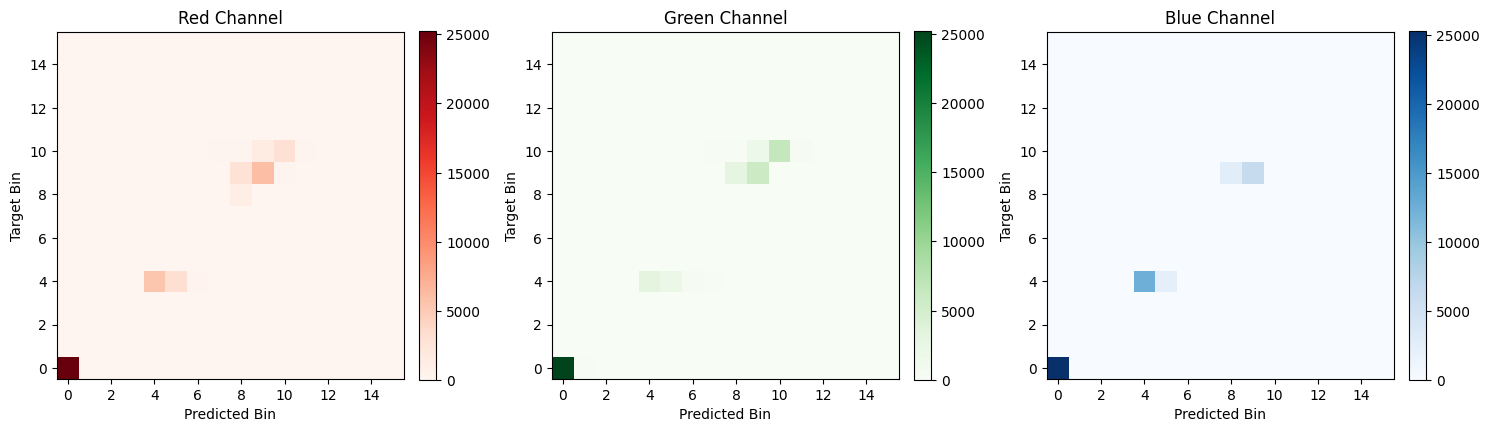

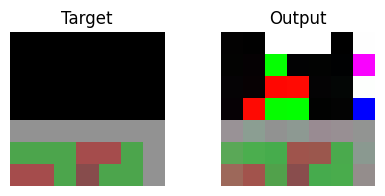

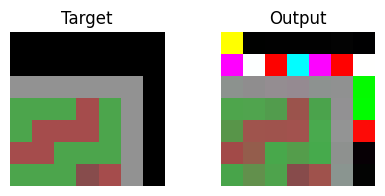

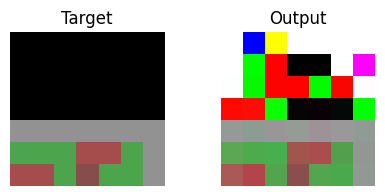

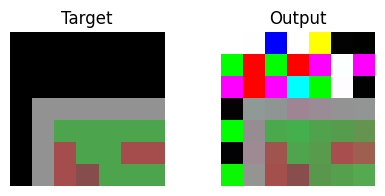

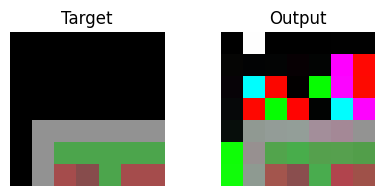

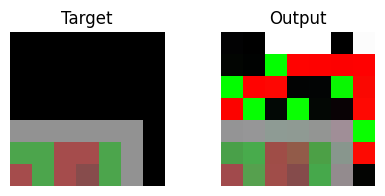

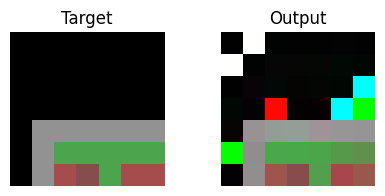

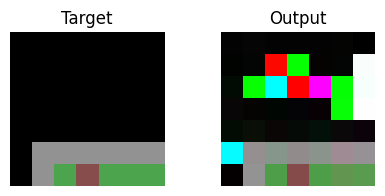

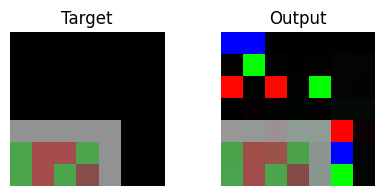

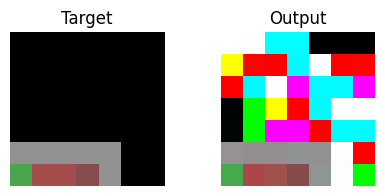

100%|██████████| 3/3 [02:11<00:00, 43.89s/it]


MSE Loss at the end of all the epochs, test: 32.944541931152344


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 	 Loss train 	 Loss test
1/100	 2596.0825		 2644.1074
2/100	 2497.7817		 2548.1714
3/100	 2434.6309		 2487.2275
4/100	 2405.3936		 2472.2632
5/100	 2365.4519		 2438.7124
6/100	 2347.1316		 2426.7205
7/100	 2324.4233		 2408.6997
8/100	 2306.3333		 2393.8958
9/100	 2290.9265		 2385.2349
10/100	 2278.0469		 2378.0688
11/100	 2263.1309		 2370.0613
12/100	 2247.9402		 2363.7393
13/100	 2238.8818		 2362.8359
14/100	 2224.9375		 2354.4585
15/100	 2209.5996		 2345.5300
16/100	 2184.7229		 2329.7668
17/100	 2152.7363		 2301.0442
18/100	 2110.3208		 2265.0464
19/100	 2045.4447		 2203.6826
20/100	 1948.8696		 2089.0881
21/100	 1816.8507		 1903.5150
22/100	 1699.8278		 1767.6718
23/100	 1565.0913		 1615.2152
24/100	 1457.9443		 1492.2787
25/100	 1374.0673		 1403.7441
26/100	 1309.0583		 1330.7487
27/100	 1262.7928		 1276.5482
28/100	 1230.4497		 1242.6998
29/100	 1183.0443		 1192.4655
30/100	 1147.7319		 1155.5425
31/100	 1118.9448		 1124.1110
32/100	 1092.4498		 1097.2971
33/100	 1068.4335	

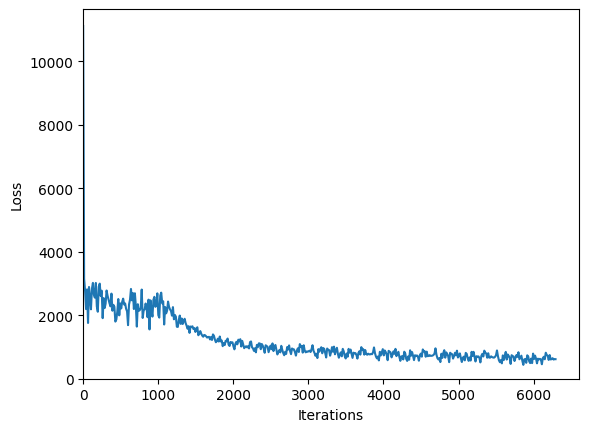

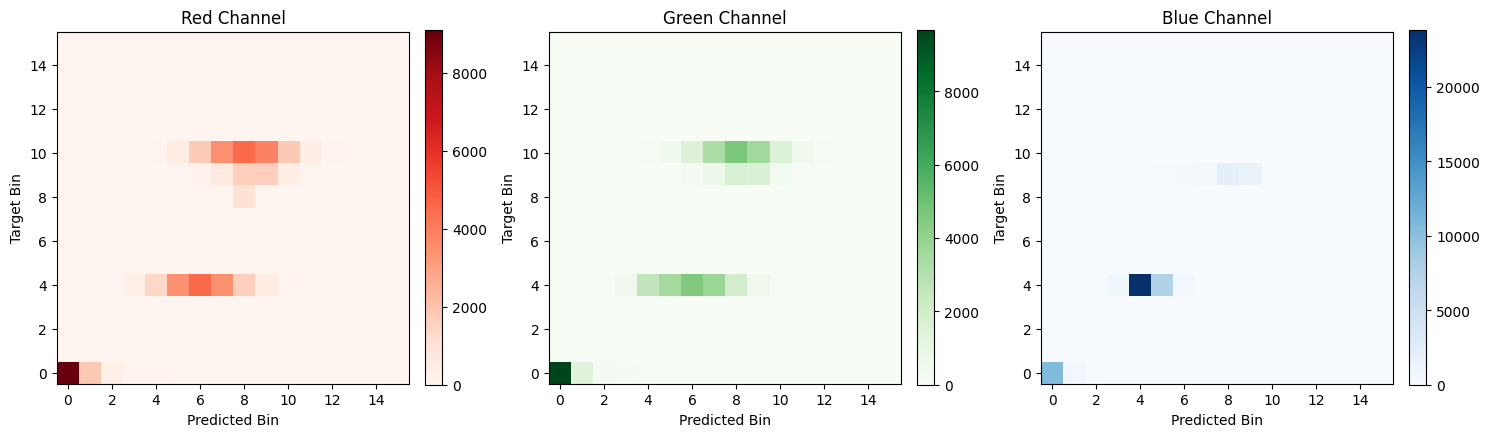

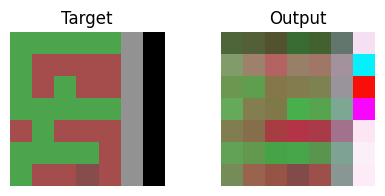

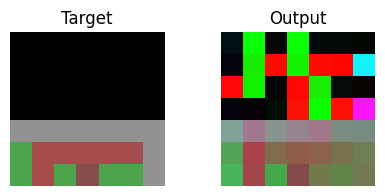

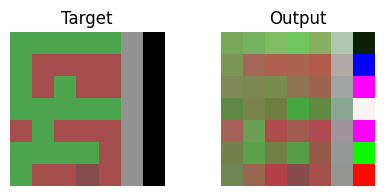

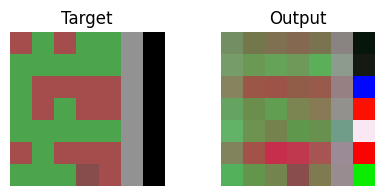

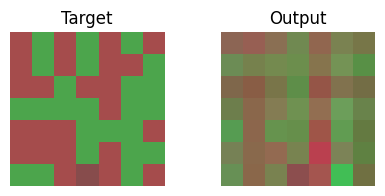

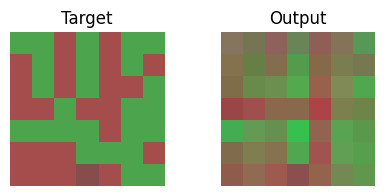

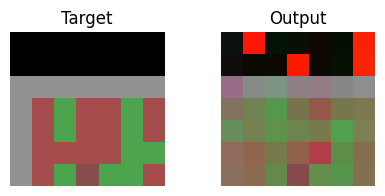

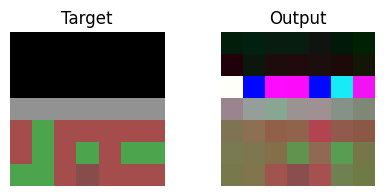

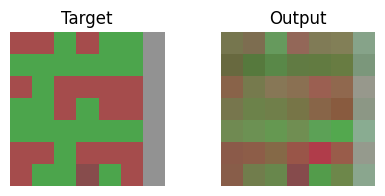

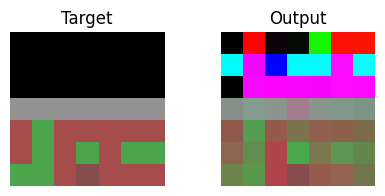

 33%|███▎      | 1/3 [00:43<01:26, 43.31s/it]

MSE Loss at the end of all the epochs, test: 670.4996337890625
Epoch 	 Loss train 	 Loss test
1/100	 2487.3286		 2557.7480
2/100	 2402.7969		 2451.7795
3/100	 2350.9646		 2394.0215
4/100	 2326.9734		 2371.8975
5/100	 2273.4387		 2328.5894
6/100	 2246.1743		 2307.2302
7/100	 2233.5754		 2296.9028
8/100	 2215.5608		 2289.3284
9/100	 2197.0962		 2277.6597
10/100	 2186.1917		 2273.5112
11/100	 2176.1394		 2269.4272
12/100	 2178.3108		 2277.2095
13/100	 2170.3669		 2269.4504
14/100	 2167.0007		 2273.6069
15/100	 2160.4075		 2264.3486
16/100	 2145.0139		 2252.3909
17/100	 2122.1167		 2243.2986
18/100	 2101.5193		 2232.8887
19/100	 2088.8870		 2221.4570
20/100	 2056.2087		 2183.7817
21/100	 2042.3868		 2167.6003
22/100	 2011.7502		 2125.3838
23/100	 1951.1006		 2052.7068
24/100	 1870.9161		 1957.0229
25/100	 1779.0076		 1844.3809
26/100	 1683.4492		 1714.7346
27/100	 1553.4065		 1555.6886
28/100	 1452.7507		 1425.6044
29/100	 1399.0035		 1371.1792
30/100	 1333.1710		 1296.8737
31/100	 1278.69

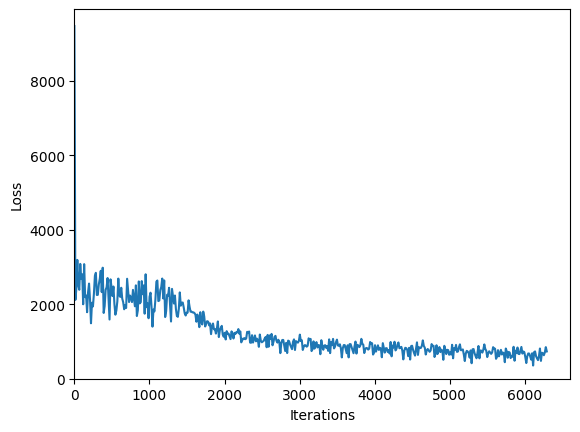

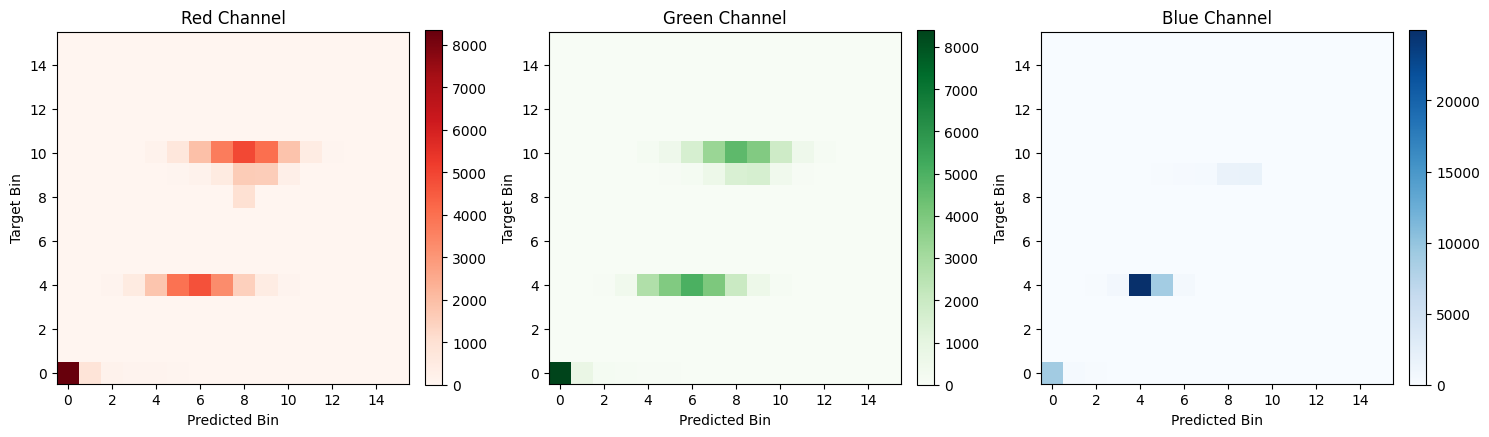

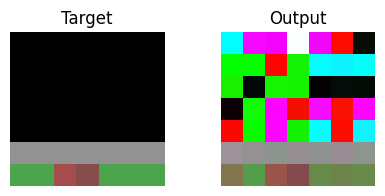

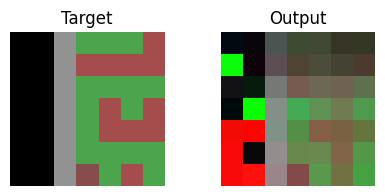

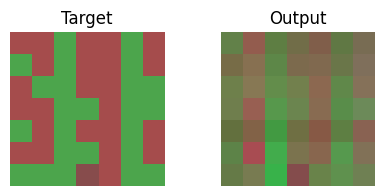

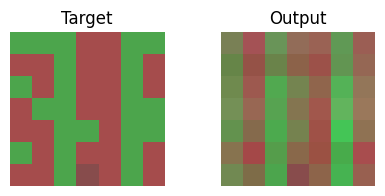

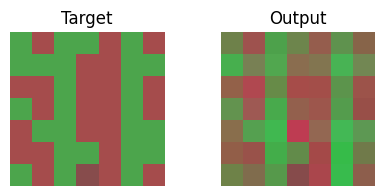

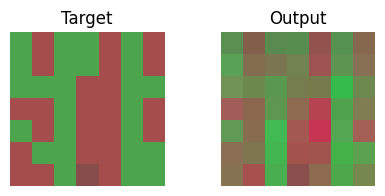

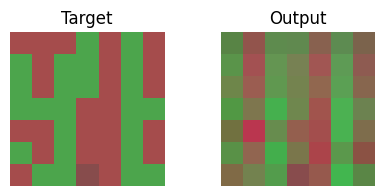

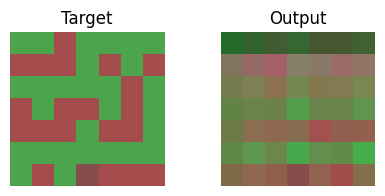

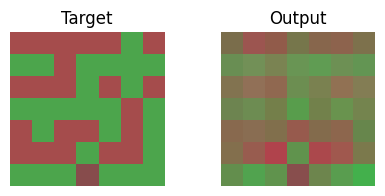

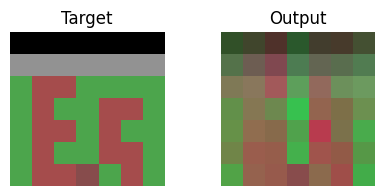

 67%|██████▋   | 2/3 [01:27<00:43, 43.82s/it]

MSE Loss at the end of all the epochs, test: 701.2562255859375
Epoch 	 Loss train 	 Loss test
1/100	 2614.0593		 2603.1953
2/100	 2477.9197		 2484.1284
3/100	 2363.7947		 2374.8115
4/100	 2325.3972		 2340.4255
5/100	 2305.6521		 2324.0552
6/100	 2288.3528		 2307.5232
7/100	 2252.3206		 2277.5957
8/100	 2226.2957		 2258.0271
9/100	 2217.3875		 2254.7932
10/100	 2202.4451		 2248.9126
11/100	 2193.0066		 2245.2463
12/100	 2178.3521		 2246.3706
13/100	 2177.3359		 2253.8303
14/100	 2174.7937		 2257.2876
15/100	 2158.0537		 2245.4287
16/100	 2142.2646		 2233.4224
17/100	 2136.5430		 2229.5051
18/100	 2105.3567		 2194.3335
19/100	 2065.6848		 2151.2805
20/100	 2016.2401		 2107.4592
21/100	 1971.2773		 2051.1951
22/100	 1914.4468		 1998.9968
23/100	 1876.0988		 1964.7467
24/100	 1797.6863		 1873.6206
25/100	 1690.6515		 1771.2615
26/100	 1585.8055		 1656.2340
27/100	 1495.8571		 1561.3925
28/100	 1417.3309		 1478.8602
29/100	 1339.1271		 1402.6262
30/100	 1301.4003		 1354.7301
31/100	 1244.09

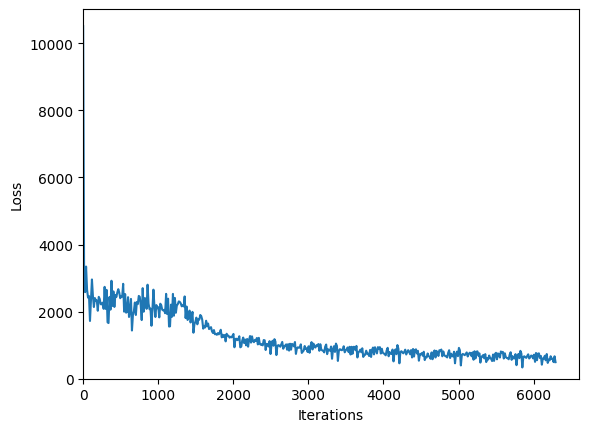

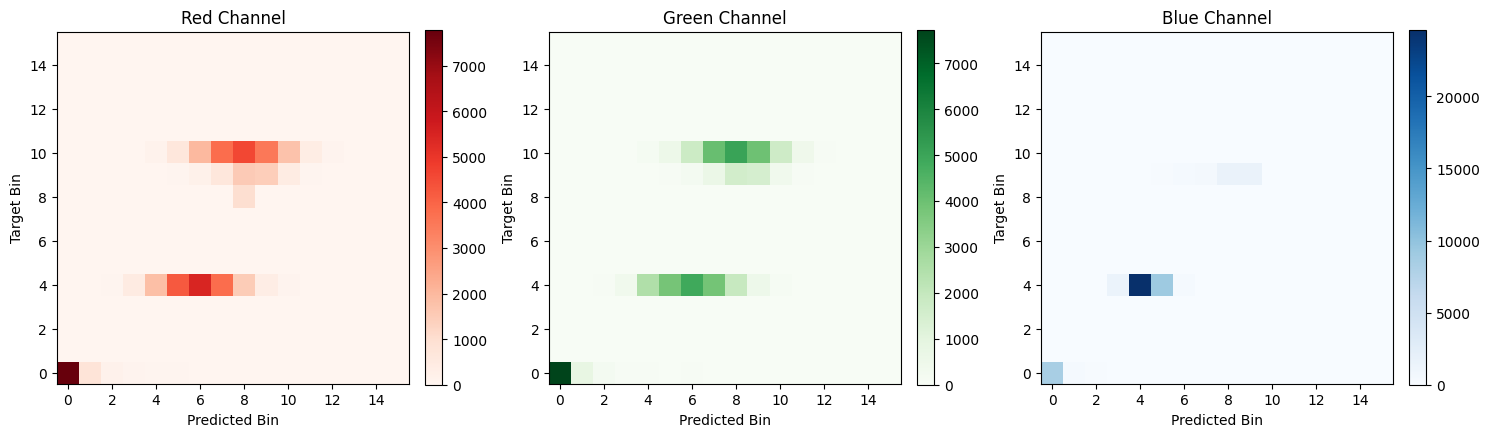

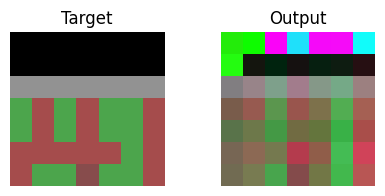

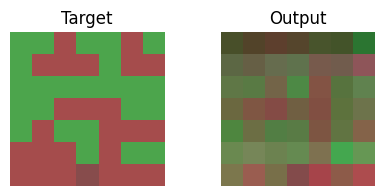

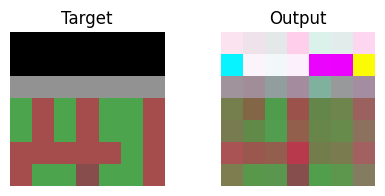

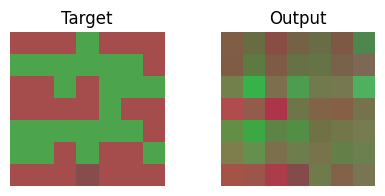

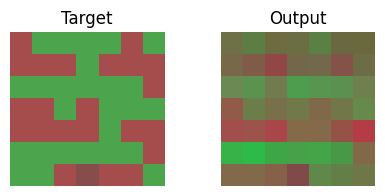

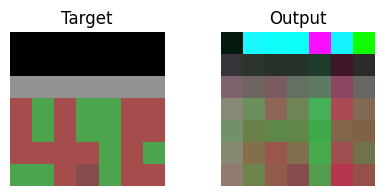

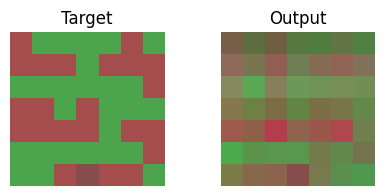

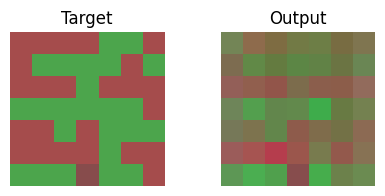

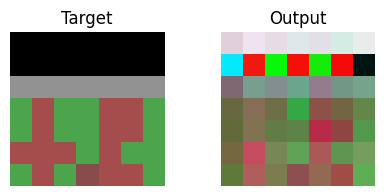

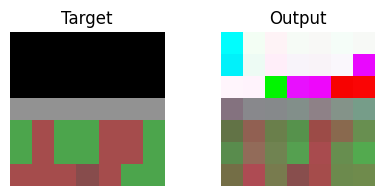

100%|██████████| 3/3 [02:11<00:00, 43.96s/it]


MSE Loss at the end of all the epochs, test: 718.0066528320312


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 	 Loss train 	 Loss test
1/100	 1823.4095		 1407.3611
2/100	 1783.1962		 1393.0294
3/100	 1769.4324		 1393.9022
4/100	 1757.1244		 1395.4996
5/100	 1740.3829		 1386.8973
6/100	 1719.3699		 1377.3015
7/100	 1709.2638		 1375.2501
8/100	 1694.3121		 1363.9662
9/100	 1679.3815		 1350.5183
10/100	 1666.8290		 1337.2748
11/100	 1655.3593		 1330.0505
12/100	 1646.3470		 1324.0187
13/100	 1640.6261		 1320.2522
14/100	 1635.7146		 1312.2375
15/100	 1625.8414		 1304.8414
16/100	 1615.7041		 1301.1671
17/100	 1610.6112		 1298.3728
18/100	 1609.5380		 1303.4653
19/100	 1594.3057		 1296.1068
20/100	 1582.3591		 1290.7684
21/100	 1583.5443		 1294.1449
22/100	 1579.6390		 1295.8203
23/100	 1579.4415		 1301.0586
24/100	 1571.9093		 1307.9785
25/100	 1564.0835		 1295.2537
26/100	 1559.2855		 1297.5002
27/100	 1553.7346		 1292.6984
28/100	 1548.1560		 1294.7301
29/100	 1534.8541		 1289.5570
30/100	 1525.3197		 1284.2256
31/100	 1504.7654		 1280.2234
32/100	 1505.9391		 1290.7438
33/100	 1495.9797	

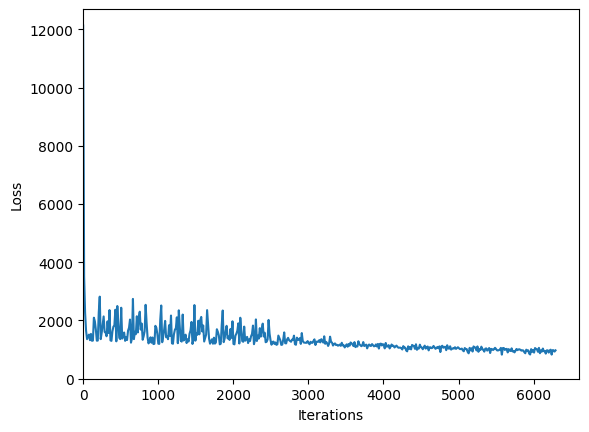

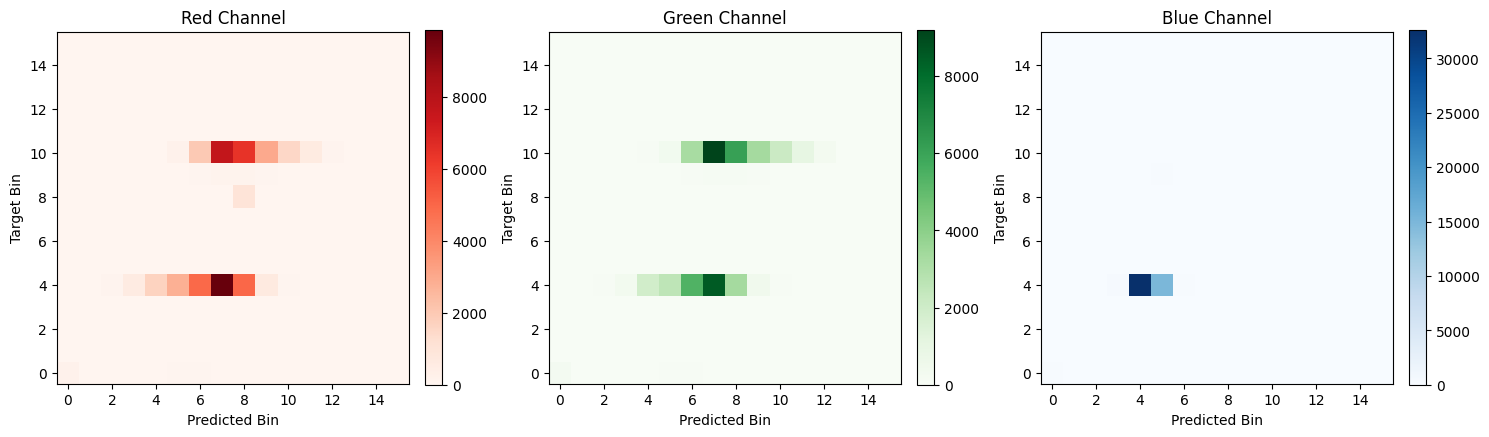

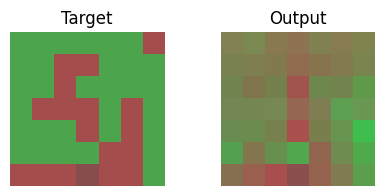

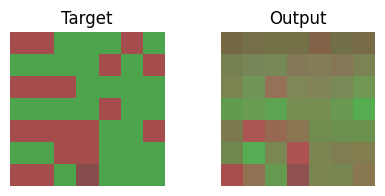

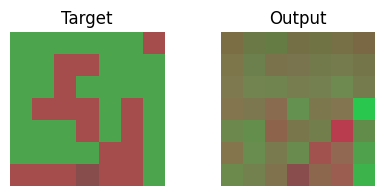

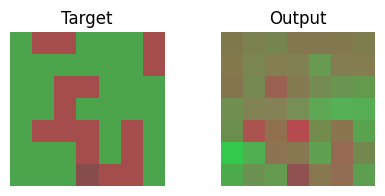

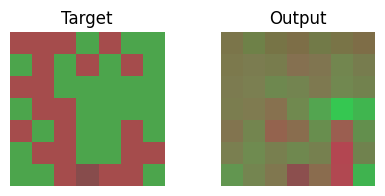

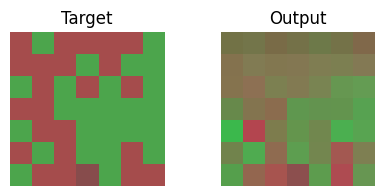

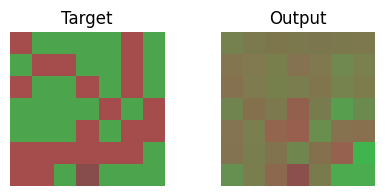

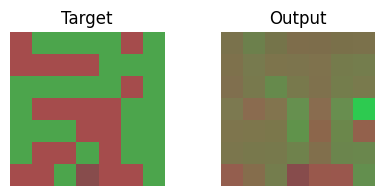

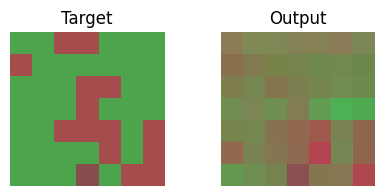

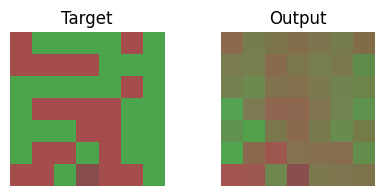

 33%|███▎      | 1/3 [00:42<01:25, 42.88s/it]

MSE Loss at the end of all the epochs, test: 1074.120361328125
Epoch 	 Loss train 	 Loss test
1/100	 1875.5123		 1659.7753
2/100	 1808.5286		 1603.3588
3/100	 1794.2566		 1598.3966
4/100	 1770.7075		 1580.4210
5/100	 1769.4698		 1584.8761
6/100	 1741.2277		 1560.0410
7/100	 1726.7605		 1550.2289
8/100	 1711.6718		 1538.2056
9/100	 1695.5693		 1527.7849
10/100	 1685.2861		 1524.2860
11/100	 1675.4218		 1517.1321
12/100	 1670.8220		 1515.9111
13/100	 1655.9879		 1502.5750
14/100	 1646.0184		 1496.2289
15/100	 1644.2458		 1499.4308
16/100	 1630.0977		 1487.5626
17/100	 1622.4459		 1480.9899
18/100	 1615.7107		 1481.5167
19/100	 1615.2990		 1486.1838
20/100	 1609.6415		 1487.4995
21/100	 1622.1539		 1491.7213
22/100	 1604.4425		 1486.7134
23/100	 1599.9460		 1476.4565
24/100	 1591.6483		 1475.1064
25/100	 1571.7224		 1467.7542
26/100	 1576.9579		 1464.9150
27/100	 1563.7087		 1454.4207
28/100	 1548.5490		 1448.7461
29/100	 1547.6997		 1458.1660
30/100	 1532.3251		 1449.7153
31/100	 1529.95

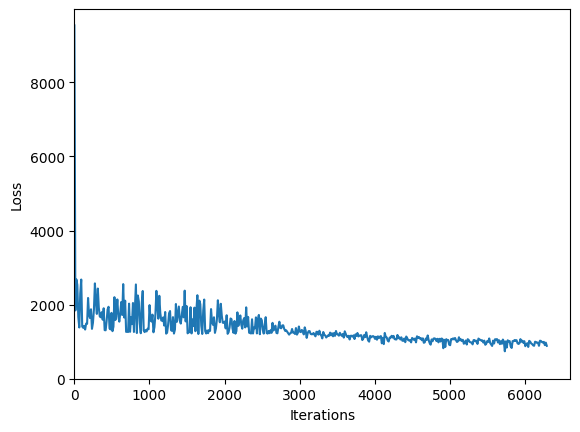

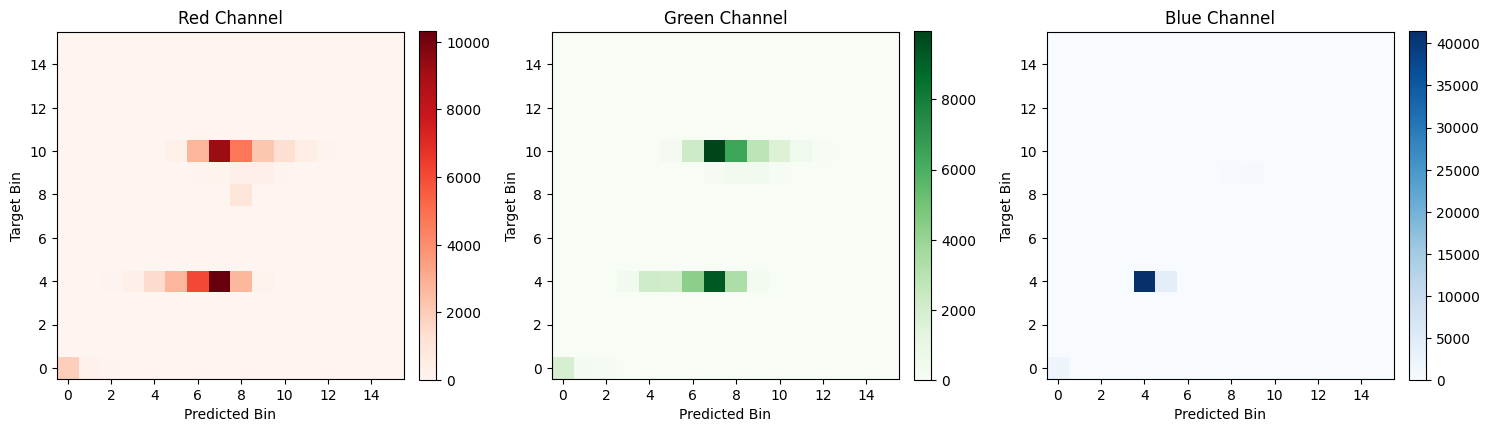

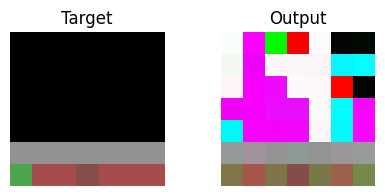

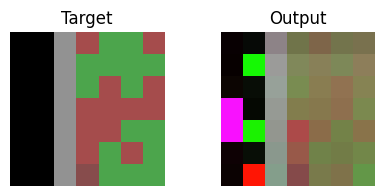

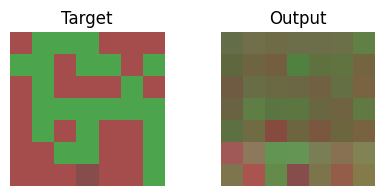

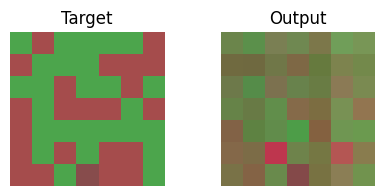

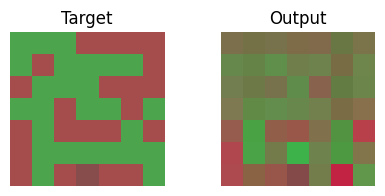

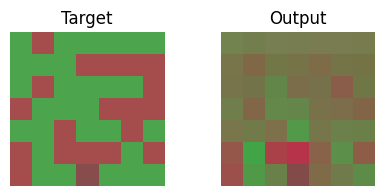

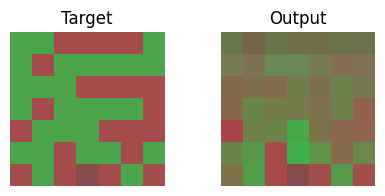

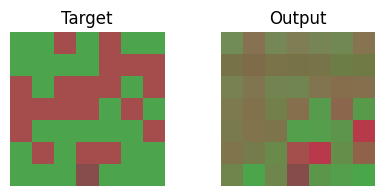

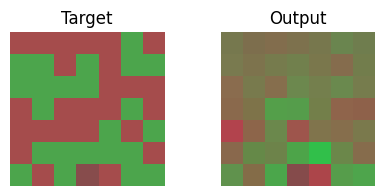

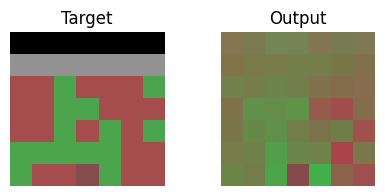

 67%|██████▋   | 2/3 [01:26<00:43, 43.10s/it]

MSE Loss at the end of all the epochs, test: 1000.0489501953125
Epoch 	 Loss train 	 Loss test
1/100	 1925.2678		 1312.3715
2/100	 1888.8623		 1305.4446
3/100	 1869.4894		 1304.4409
4/100	 1853.2284		 1301.5951
5/100	 1845.2103		 1300.9093
6/100	 1825.0085		 1291.8052
7/100	 1816.1016		 1291.7035
8/100	 1810.0922		 1287.4165
9/100	 1789.7482		 1269.0995
10/100	 1776.9634		 1255.7241
11/100	 1771.3628		 1253.1526
12/100	 1780.8932		 1260.8668
13/100	 1760.0093		 1247.9242
14/100	 1753.4175		 1244.3832
15/100	 1753.7582		 1239.3274
16/100	 1749.3728		 1231.4926
17/100	 1745.5173		 1230.8423
18/100	 1738.5768		 1232.6979
19/100	 1747.2378		 1243.0911
20/100	 1719.5693		 1238.4921
21/100	 1728.0378		 1254.7094
22/100	 1706.2108		 1235.2782
23/100	 1697.6854		 1234.5959
24/100	 1686.9113		 1234.8790
25/100	 1685.4900		 1240.2489
26/100	 1663.4484		 1233.3939
27/100	 1647.9115		 1234.1378
28/100	 1684.6659		 1239.7216
29/100	 1612.5746		 1222.0105
30/100	 1576.0134		 1217.5585
31/100	 1571.1

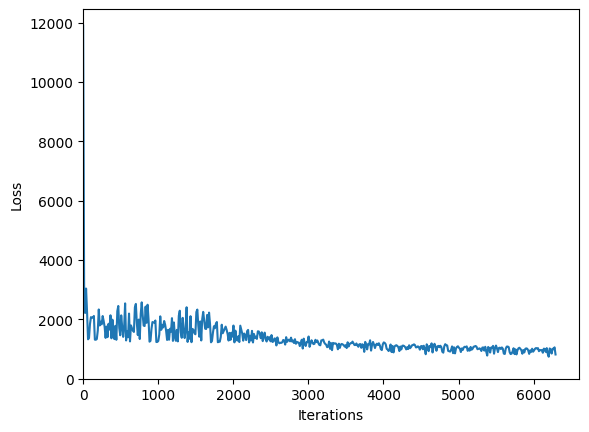

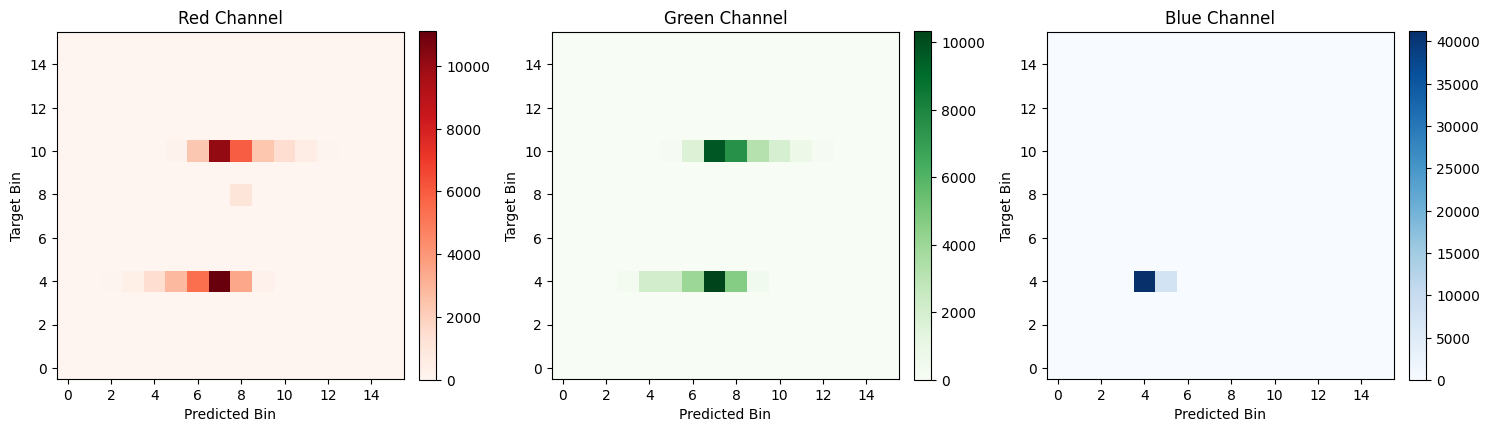

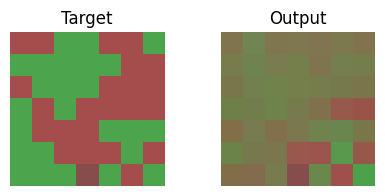

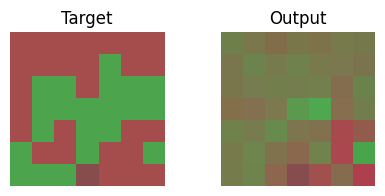

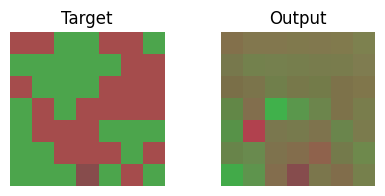

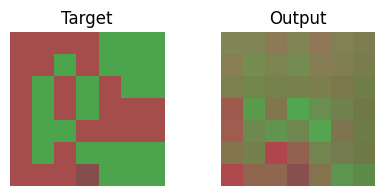

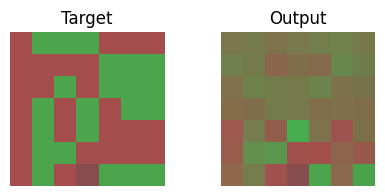

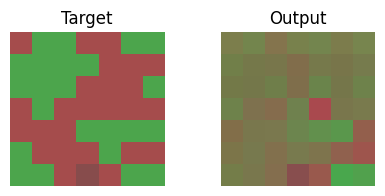

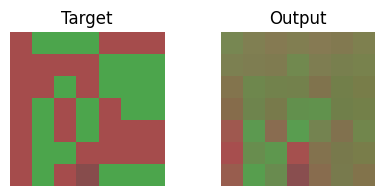

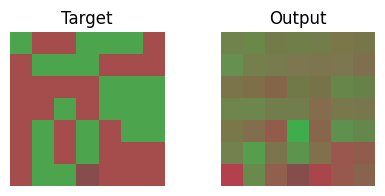

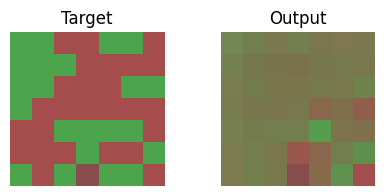

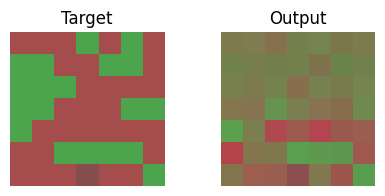

100%|██████████| 3/3 [02:09<00:00, 43.05s/it]


MSE Loss at the end of all the epochs, test: 1031.220703125


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 	 Loss train 	 Loss test
1/100	 3034.7612		 3094.5989
2/100	 2970.7346		 3022.9443
3/100	 2951.5366		 3008.2156
4/100	 2943.1531		 3001.7705
5/100	 2938.1379		 3000.9529
6/100	 2934.4858		 3002.3137
7/100	 2930.4922		 2999.1033
8/100	 2923.1160		 2995.4585
9/100	 2918.2922		 2993.7439
10/100	 2913.0510		 2989.7207
11/100	 2905.1770		 2982.6704
12/100	 2894.5479		 2973.9258
13/100	 2891.0991		 2965.2461
14/100	 2871.2378		 2956.8193
15/100	 2851.8931		 2929.5774
16/100	 2826.2869		 2889.0596
17/100	 2771.2202		 2824.3220
18/100	 2684.1218		 2726.0161
19/100	 2566.5444		 2615.9792
20/100	 2432.9207		 2475.9177
21/100	 2272.6375		 2330.5649
22/100	 2032.9128		 2097.8101
23/100	 1744.3230		 1799.3860
24/100	 1515.1632		 1556.2572
25/100	 1340.5792		 1361.1212
26/100	 1209.0430		 1216.1876
27/100	 1087.3231		 1080.6124
28/100	 985.3921		 966.5145
29/100	 905.8682		 877.7937
30/100	 850.0701		 820.2823
31/100	 780.8481		 745.6422
32/100	 724.4241		 685.6430
33/100	 676.9331		 635.4279


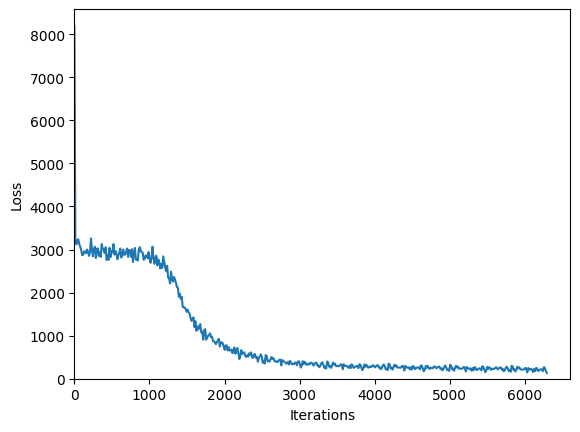

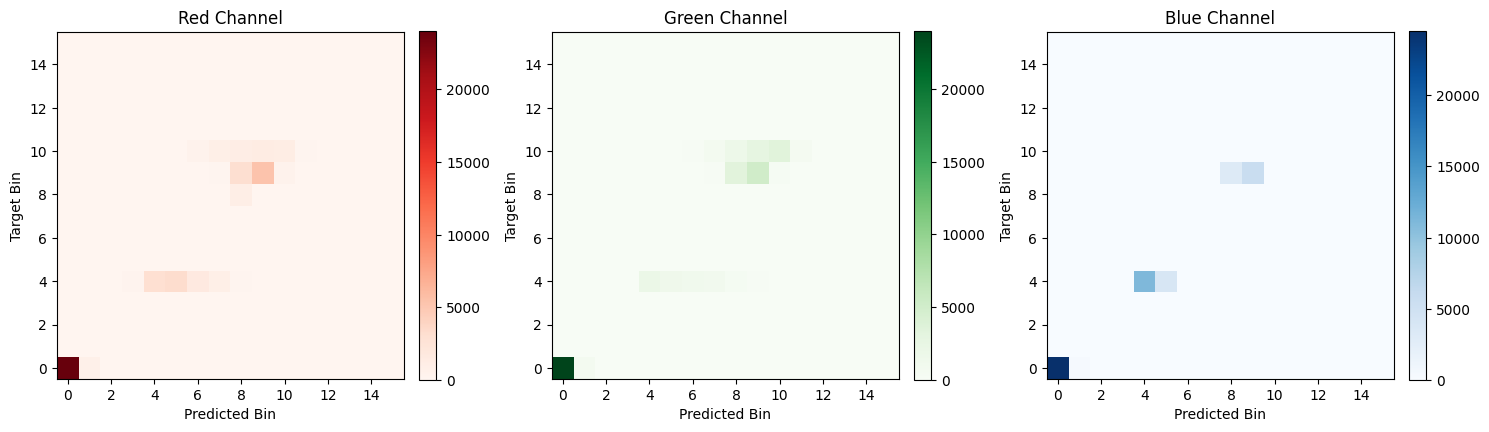

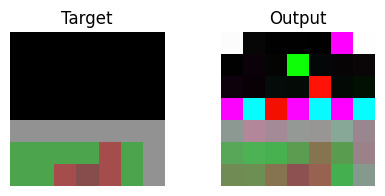

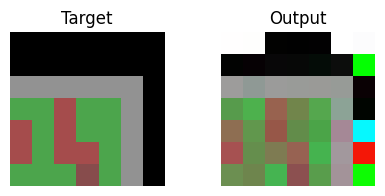

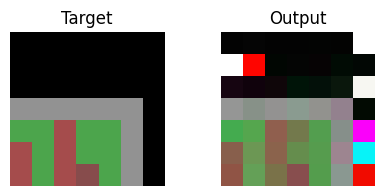

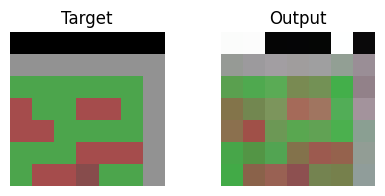

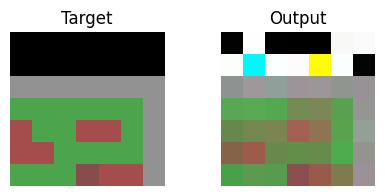

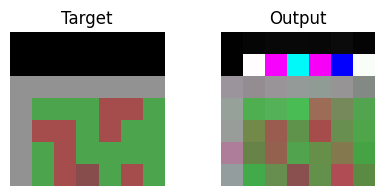

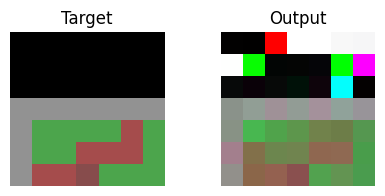

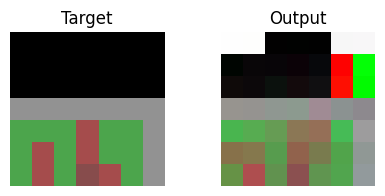

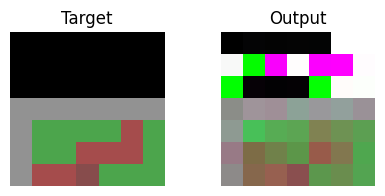

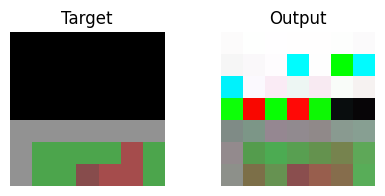

 33%|███▎      | 1/3 [00:42<01:25, 42.86s/it]

MSE Loss at the end of all the epochs, test: 156.5544891357422
Epoch 	 Loss train 	 Loss test
1/100	 3042.5825		 3006.2944
2/100	 3000.1172		 2964.4592
3/100	 2986.5623		 2960.5637
4/100	 2971.6304		 2949.8303
5/100	 2961.3601		 2941.8665
6/100	 2953.6704		 2935.8882
7/100	 2946.4934		 2930.5994
8/100	 2941.2656		 2927.9231
9/100	 2937.1475		 2922.2454
10/100	 2934.3052		 2922.3176
11/100	 2932.4070		 2921.8379
12/100	 2928.7861		 2916.5491
13/100	 2928.7559		 2916.6160
14/100	 2919.7175		 2910.8010
15/100	 2915.9563		 2906.2544
16/100	 2881.4146		 2876.5337
17/100	 2833.6379		 2832.1572
18/100	 2756.7976		 2750.2600
19/100	 2658.5188		 2650.1316
20/100	 2555.2300		 2542.2083
21/100	 2457.1929		 2445.2576
22/100	 2367.3167		 2364.4150
23/100	 2283.4810		 2289.8923
24/100	 2201.0083		 2214.3025
25/100	 2089.5547		 2103.7834
26/100	 1894.5236		 1904.4939
27/100	 1751.0695		 1761.3566
28/100	 1586.2845		 1599.1879
29/100	 1439.1027		 1447.4215
30/100	 1309.5494		 1316.8488
31/100	 1203.19

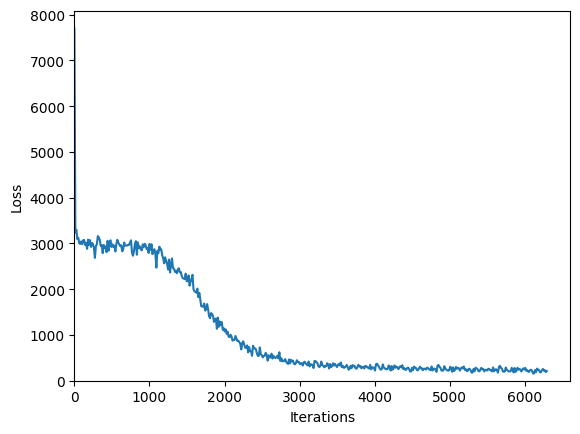

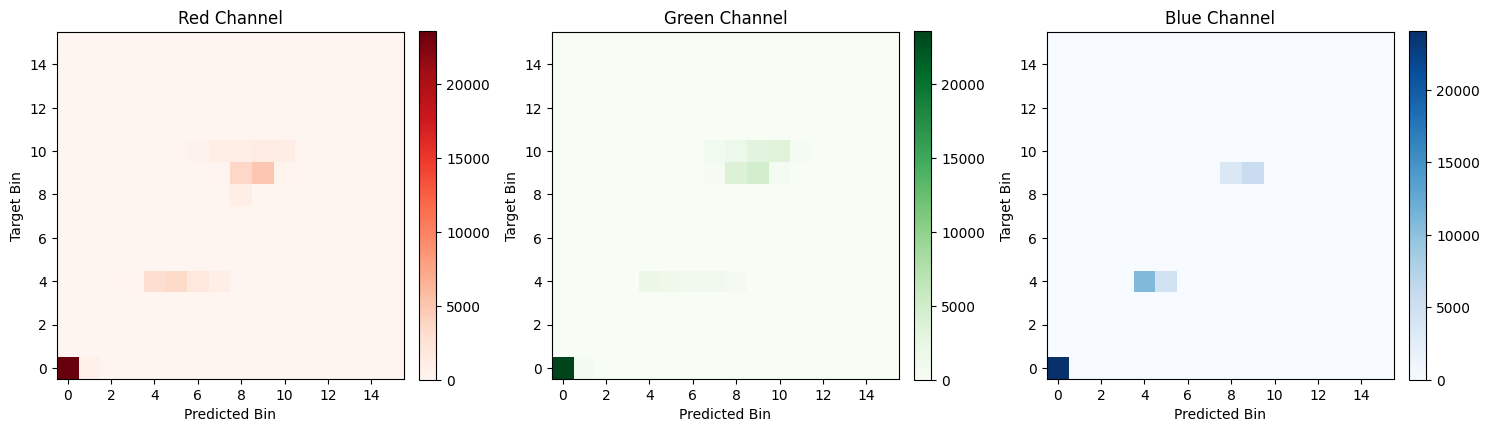

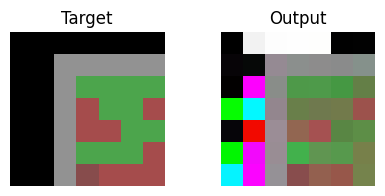

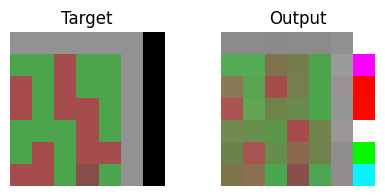

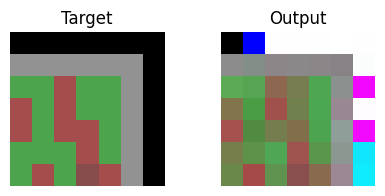

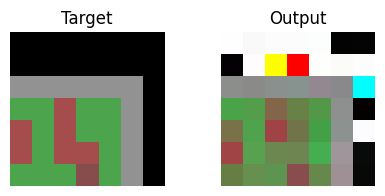

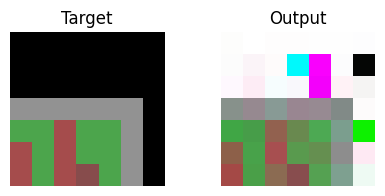

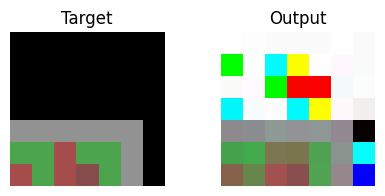

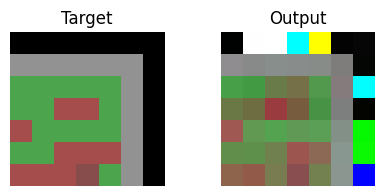

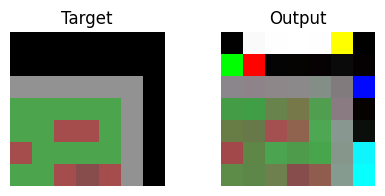

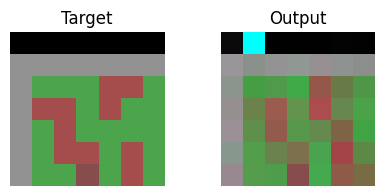

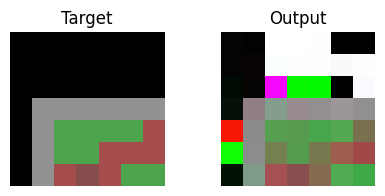

 67%|██████▋   | 2/3 [01:25<00:42, 42.93s/it]

MSE Loss at the end of all the epochs, test: 162.11383056640625
Epoch 	 Loss train 	 Loss test
1/100	 3040.0522		 3094.6775
2/100	 2990.2295		 3044.3035
3/100	 2971.4014		 3028.3064
4/100	 2957.2380		 3014.4644
5/100	 2950.5332		 3010.9216
6/100	 2944.3577		 3006.8452
7/100	 2937.3728		 3002.8706
8/100	 2932.8101		 2998.8223
9/100	 2928.0024		 2996.9426
10/100	 2923.5767		 2994.6794
11/100	 2917.0845		 2990.5549
12/100	 2913.7029		 2994.9775
13/100	 2909.0947		 2997.1248
14/100	 2904.2302		 2994.9868
15/100	 2885.8391		 2989.9917
16/100	 2831.2139		 2937.3264
17/100	 2765.8977		 2858.5515
18/100	 2704.2354		 2797.8994
19/100	 2641.1672		 2731.2493
20/100	 2572.7402		 2669.4822
21/100	 2486.6714		 2577.7253
22/100	 2371.6926		 2449.8650
23/100	 2230.5320		 2290.7896
24/100	 2041.9271		 2078.3269
25/100	 1797.8136		 1803.7131
26/100	 1582.5303		 1562.8517
27/100	 1376.5715		 1329.1758
28/100	 1211.5480		 1146.5703
29/100	 1070.6218		 989.4757
30/100	 954.9948		 863.6436
31/100	 875.3431	

 67%|██████▋   | 2/3 [01:55<00:57, 57.53s/it]

70/100	 273.8044		 205.5678


KeyboardInterrupt: 

In [42]:
config_names = [config["config_name"] for config in configs]
loaded_models = {k1: {k2: [{k3: None for k3 in seeds} for i in range(len(map_files))] for k2 in config_names} for k1 in n_action_seq}
processed_inputs = {k1: {k2: [{k3: None for k3 in seeds} for i in range(len(map_files))] for k2 in config_names} for k1 in n_action_seq}

for n_act in n_action_seq:
    for c in range(len(map_files)):
        for seed in tqdm(seeds):
            image_list_train, pos_list_train, dir_list_train, image_list_test, pos_list_test, dir_list_test = loaded_data[c][seed]
            X_train,X_test= torch.tensor(image_list_train, dtype=torch.int64),torch.tensor(image_list_test, dtype=torch.int64)

            target_train = X_train[n_act:]
            input_train = X_train[:-n_act]
            target_test = X_test[n_act:]
            input_test = X_test[:-n_act]

            train_actions = X_train[:,-1]
            test_actions = X_test[:,-1] 
            input_train = torch.cat((input_train[:,:-1],train_actions.unfold(0, n_act, 1)[:-1]),dim=1)
            input_test = torch.cat((input_test[:,:-1],test_actions.unfold(0, n_act, 1)[:-1]),dim=1)
            
            scaling_factor=1

            for config in configs:

                if config["observation_space"]=="allocentric":
                    img_width, img_height = config["map_dims"][0], config["map_dims"][1]
                else:
                    img_width, img_height = config["egocentric_view_size"], config["egocentric_view_size"]

                input_train_processed = torch.stack([process_input(x, 'in',img_width,img_height,scaling_factor,3,n_actions=n_act) for x in input_train])
                target_train_processed = torch.stack([process_input(x, 'out',img_width,img_height,scaling_factor,3,n_actions=n_act) for x in target_train])
                input_test_processed = torch.stack([process_input(x, 'in',img_width,img_height,scaling_factor,3,n_actions=n_act) for x in input_test])
                target_test_processed = torch.stack([process_input(x, 'out',img_width,img_height,scaling_factor,3,n_actions=n_act) for x in target_test])


                processed_inputs[n_act][config["config_name"]][c][seed] = [input_train_processed, input_test_processed, target_train_processed, target_test_processed]

                latent_size=config["latent_size"]+3*n_act
                hidden_fac=15
                img_channels=3
                input_size=input_train_processed.size(1)
                output_size = target_train_processed.size(1)
                torch.manual_seed(config["model_seed"])
                torch.use_deterministic_algorithms(True)
                train_flag = True
                device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
                if config['model_type'] == "autoencoder_no_rnn":
                    model = predictive_models.AutoencoderWithoutRNN(input_size, output_size, hidden_fac, latent_size,device)
                elif config["model_type"]=="autoencoder_rnn":
                    model = predictive_models.AutoencoderWithRNN(input_size, output_size, hidden_fac, latent_size,device)
                elif config["model_type"]=="autoencoder_rnn_separate_action":
                    model = predictive_models.AutoencoderRNNSeparateAction(img_width*img_height*img_channels,input_size-img_width*img_height*img_channels, output_size, hidden_fac, latent_size,device,weight_init=False,encoder_activation="leaky_relu")
                else:
                    model = predictive_models.AutoencoderInputs(img_width*img_height*img_channels,device)
                    train_flag = False
                model.to(device)
                n_epochs, batch_size = config['number_epochs'], config['batch_size']
                MODEL_PATH = f"trained_models/multiple_action_sequences_wi/{n_act}_{config['predictive_model_path']}_{map_labels[c]}_{seed}.pt"
                METRICS_DIR = f"outputs/multiple_action_sequences_wi/model_evaluation/{n_act}/{config['predictive_model_path']}_{map_labels[c]}_{seed}"
                Path(METRICS_DIR).mkdir(parents=True, exist_ok=True)
                METRICS_PATH = f"{METRICS_DIR}/metrics.csv"
                if (config["load_trained_model_if_existent"] and os.path.exists(MODEL_PATH)) and config["model_type"]!="inputs":
                    try:
                        model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
                        print("Loaded model!")
                        with open(f"outputs/multiple_action_sequences_wi/model_evaluation/{n_act}/{config['predictive_model_path']}_{map_labels[c]}_{seed}/metrics.json", "r") as f:
                            metrics = json.load(f)
                        train_flag = False
                    except (RuntimeError, KeyError, EOFError) as e:
                        print("Failed to load model - will proceed to training!")
                if train_flag:
                    tracked_losses_train, tracked_losses_test = runSGD(model, input_train_processed, target_train_processed, input_test_processed, target_test_processed, device=device, n_epochs=n_epochs, batch_size=batch_size,seed=config["model_seed"],notrain=(not config["train"]))
                    if (config['save_trained_model']):
                        torch.save(model.state_dict(), MODEL_PATH)
                    dec_outputs = results_analysis.metrics_predict_rgb_with_decoding(model,config,device,scaling_factor,input_test_processed,target_test_processed,tracked_losses_train,tracked_losses_test,outdir=METRICS_DIR,nbins=16,ego_len=img_width)

                loaded_models[n_act][config["config_name"]][c][seed] = model 

#### PCA on latent space 

In [ ]:
top_components = {k1: {k2: [{k3: None for k3 in seeds} for i in range(len(map_files))] for k2 in config_names} for k1 in n_action_seq}

for n_act in n_action_seq:
    for c in range(len(map_files)):
        for seed in tqdm(seeds):
            OUT_DIR = f"outputs/multiple_action_sequences/latent_space_PCA/{map_labels[c]}_{n_act}/{seed}"
            if not os.listdir(OUT_DIR):
                input_train_processed = processed_inputs[n_act][config["config_name"]][c][seed][0]
                image_list_train, pos_list_train, dir_list_train, image_list_test, pos_list_test, dir_list_test = loaded_data[c][seed]
                model = loaded_models[n_act][config["config_name"]][c][seed]
                # latent_space_before, latent_space_after = model.get_latent(input_train_processed)
                all_latent_spaces = [(model.get_latent(i.view(1,-1).to(device))) for i in input_train_processed]
                latent_space_before = torch.stack([i[0] for i in all_latent_spaces]).squeeze(1)
                latent_space_after_list = [i[1] for i in all_latent_spaces]
                if all(val is not None for val in latent_space_after_list):
                    latent_space_after = torch.stack(latent_space_after_list).squeeze(1)
                else:
                    latent_space_after = None

                # if (config["model_type"] == "autoencoder_rnn"):
                #     latent_spaces = [[latent_space_before, "before_RNN"],[latent_space_after, "after_RNN"]]
                # else:
                latent_spaces = [[latent_space_before, ""]]
                print([n_act], config["config_name"], map_labels[c],seed)
                top_components[n_act][config["config_name"]][c][seed] = latent_space_PCA(latent_spaces,config,pos_list_train[:-n_act],dir_list_train[:-n_act],img_width,img_height,outdir=OUT_DIR)



##### Violin plots

In [8]:
data_directories = [('outputs/multiple_action_sequences/latent_space_PCA','actions'), ('outputs/variances_egocentic_input_spaces/latent_space_PCA',' inputs')]
directories_to_use = ['8x8_colors', '20x20_colors', '50x50_colors']

def numeric_key(s):
    parts = s.replace('x', ' ').replace('_', ' ').split()
    return [int(p) for p in parts if p.isdigit()]

OUT_DIR_VAR = f"outputs/multiple_action_sequences/latent_space_PCA/"
Path(OUT_DIR_VAR).mkdir(parents=True, exist_ok=True)
values, labels = [],[]
metric_label = "variance of first 3 principal components" 
for data_directory,label in data_directories:
    print(sorted(os.listdir(data_directory),reverse=True))
    for map_label in sorted(os.listdir(data_directory), key=numeric_key):
        if map_label[-4:] != ".png" and (data_directory == 'outputs/multiple_action_sequences/latent_space_PCA' or map_label in directories_to_use):
            print(map_label)
            values.append([])
            labels.append(map_label+label)
            for seed in sorted(os.listdir(f"{data_directory}/{map_label}"),reverse=True):
                for filename in sorted(os.listdir(f"{data_directory}/{map_label}/{seed}"),reverse=True):
                    if filename.endswith('.json'):
                        path = os.path.join(Path(f"{data_directory}/{map_label}/{seed}"), filename)
                        with open(path, 'r') as f:
                            data = json.load(f)                                
                            values[-1] += [data["cumulative_variance"][2]]

wrapped_labels = [textwrap.fill(label, width=30) for label in labels]
df = pd.DataFrame([{'L': l, 'V': v} for l, vs in zip(wrapped_labels, values) for v in vs])
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='V', y='L',hue= 'L', palette='viridis', inner='box', linewidth=1.5)
plt.ylabel('Model type'); plt.xlabel(f"PCA {metric_label}")
plt.savefig(f"{OUT_DIR_VAR}/variance_violin_zoom.png", bbox_inches='tight')
plt.xlim(0, 1)
plt.savefig(f"{OUT_DIR_VAR}/variance_violin.png", bbox_inches='tight'); plt.clf()

['variance_violin_zoom.png', 'variance_violin.png', '8x8_colors_8', '8x8_colors_4', '8x8_colors_2', '8x8_colors_16', '8x8_colors_1', '50x50_colors_8', '50x50_colors_4', '50x50_colors_2', '50x50_colors_16', '50x50_colors_1', '20x20_colors_8', '20x20_colors_4', '20x20_colors_2', '20x20_colors_16', '20x20_colors_1']
8x8_colors_1
8x8_colors_2
8x8_colors_4
8x8_colors_8
8x8_colors_16
20x20_colors_1
20x20_colors_2
20x20_colors_4
20x20_colors_8
20x20_colors_16
50x50_colors_1
50x50_colors_2
50x50_colors_4
50x50_colors_8
50x50_colors_16
['variance_violin_zoom.png', 'variance_violin.png', '8x8_walls', '8x8_empty', '8x8_colorswalls', '8x8_colors', '50x50_walls', '50x50_empty', '50x50_colorswalls', '50x50_colors', '20x20_walls', '20x20_empty', '20x20_colorswalls', '20x20_colors', '14x14_walls', '14x14_empty', '14x14_colorswalls', '14x14_colors']
8x8_colors
20x20_colors
50x50_colors


<Figure size 800x600 with 0 Axes>

#### Firing fields

In [49]:
top_components = {k1: {k2: [{k3: None for k3 in seeds} for i in range(len(map_files))] for k2 in config_names} for k1 in n_action_seq}

units_to_test = [i for i in range(50)]
firing_fields = [{k1: {k2: [{k3: [[0 for _ in range(dims[i][0])] for _ in range(dims[i][1])] for k3 in seeds} for i in range(len(map_files))] for k2 in config_names} for k1 in n_action_seq} for _ in range(len(units_to_test))]

for n_act in n_action_seq:
    for c in range(len(map_files)):
        for seed in tqdm(seeds):
            input_train_processed = processed_inputs[n_act][config["config_name"]][c][seed][0]
            image_list_train, pos_list_train, dir_list_train, image_list_test, pos_list_test, dir_list_test = loaded_data[c][seed]
            model = loaded_models[n_act][config["config_name"]][c][seed]
            # latent_space_before, latent_space_after = model.get_latent(input_train_processed)
            all_latent_spaces = [(model.get_latent(i.view(1,-1).to(device))) for i in input_train_processed]
            latent_space_before = torch.stack([i[0] for i in all_latent_spaces]).squeeze(1)
            latent_space_after_list = [i[1] for i in all_latent_spaces]
            if all(val is not None for val in latent_space_after_list):
                latent_space_after = torch.stack(latent_space_after_list).squeeze(1)
            else:
                latent_space_after = None
            latent_spaces = [[latent_space_before, ""]]
            print(n_act, config["config_name"], map_labels[c],seed)
            # print(latent_space_before)
            activations = latent_space_before.mean(dim=0) # Average firing per unit
            dead_units = (activations == 0).sum().item()
            total_units = activations.shape[0]
            print(dead_units,total_units)
            for u in range(len(units_to_test)):
                
                SAVE_PATH = f"outputs/multiple_action_sequences_wi/firing_fields/{map_labels[c]}_{n_act}"
                os.makedirs(SAVE_PATH, exist_ok=True)
                # if not os.listdir(SAVE_PATH):
                if (abs(z[0][u].mean(dim=0)) > 1):
                    for z in zip(latent_space_before, pos_list_train):
                        x, y = z[1]
                        firing_fields[u][n_act][config["config_name"]][c][seed][x][y] += (z[0][units_to_test[u]].detach().cpu().item() > 0)
                    field = firing_fields[u][n_act][config["config_name"]][c][seed]
                    plt.imshow(field, cmap='viridis', origin='lower')
                    plt.title(f"Unit {units_to_test[u]}, Map {map_labels[c]}, Seed, {seed}, {n_act} actions")
                    plt.savefig(f"{SAVE_PATH}/seed_{seed}_unit_{units_to_test[u]}.png")
                    plt.close()




  0%|          | 0/3 [00:00<?, ?it/s]

1 egocentric_empty_7x7view_rnn_separate_action 8x8_colors 77243
0 50


 33%|███▎      | 1/3 [00:14<00:28, 14.09s/it]

1 egocentric_empty_7x7view_rnn_separate_action 8x8_colors 798315
0 50


 67%|██████▋   | 2/3 [00:44<00:23, 23.66s/it]

1 egocentric_empty_7x7view_rnn_separate_action 8x8_colors 101125
0 50


 67%|██████▋   | 2/3 [00:49<00:24, 24.81s/it]


KeyboardInterrupt: 

#### Single layer decoders

In [21]:
for n_act in n_action_seq:
    for c in range(len(map_files)):
        for seed in tqdm(seeds):
            model = loaded_models[n_act][config["config_name"]][c][seed]
            input_train_processed, input_test_processed = processed_inputs[n_act][config["config_name"]][c][seed][:2]
            image_list_train, pos_list_train, dir_list_train, image_list_test, pos_list_test, dir_list_test = loaded_data[c][seed]
            if config["observation_space"]=="allocentric":
                img_width, img_height = config["map_dims"][0], config["map_dims"][1]
            else:
                img_width, img_height = config["egocentric_view_size"], config["egocentric_view_size"]
            OUT_DIR_REPR = f"outputs/multiple_action_sequences/decode_latent_representations/{map_labels[c]}_{n_act}/{seed}"
            latent_size=config["latent_size"]+3*n_act
            Path(OUT_DIR_REPR).mkdir(parents=True, exist_ok=True)
            
            latent_space_before_train, latent_space_after_train = model.get_latent(input_train_processed.to(device))
            latent_space_before_test, latent_space_after_test = model.get_latent(input_test_processed.to(device))

            latent_size_repr = config["latent_size"]
            latent_representations_train = [[latent_space_before_train.detach(), ""]]
            latent_representations_test = [[latent_space_before_test.detach(), ""]]

            dads = []
            for i in range(len(latent_representations_train)):
                latent_representation_train, label = latent_representations_train[i]
                latent_representation_test, label = latent_representations_test[i]
                if not Path(f"{OUT_DIR_REPR}/{label}.json").exists():
                    dict_repr = {}
                    for variable in config["variables_for_training_decoder"]:
                        if variable == "position":
                                target_train_repr, target_test_repr = torch.tensor(pos_list_train[:-n_act]).float(), torch.tensor(pos_list_test[:-n_act]).float()
                                decoder_model = nn.Linear(latent_size_repr,2)
                                loss_type="mse"
                                metric, metric_label, output_process = results_analysis.accuracy, "accuracy",results_analysis.round
                        elif variable == "L2_dist_center":
                            target_train_repr = torch.tensor(np.sqrt((np.array(pos_list_train)[:-n_act,0]-(img_width-1)/2)**2+ (np.array(pos_list_train)[:-n_act,1]-(img_height-1)/2)**2)).float().unsqueeze(-1)
                            target_test_repr = torch.tensor(np.sqrt((np.array(pos_list_test)[:-n_act,0]-(img_width-1)/2)**2+ (np.array(pos_list_test)[:-n_act,1]-(img_height-1)/2)**2)).float().unsqueeze(-1)
                            decoder_model = nn.Linear(latent_size_repr,1)
                            loss_type="mse"
                            metric, metric_label, output_process = results_analysis.mse, "mse",results_analysis.identity
                        elif variable == "head_direction":
                            target_train_repr, target_test_repr = torch.tensor(dir_list_train[:-n_act]).long().view(-1), torch.tensor(dir_list_test[:-n_act]).long().view(-1)
                            decoder_model = nn.Linear(latent_size_repr,4)
                            loss_type="cel"
                            metric, metric_label, output_process = results_analysis.accuracy, "accuracy", results_analysis.argmax
                        tracked_losses_train_repr, tracked_losses_test_repr = runSGD(decoder_model,latent_representation_train,target_train_repr,latent_representation_test,target_test_repr,device,criterion=loss_type,n_epochs=100,batch_size=256,shuffle=False,hide_plot=True,lr=.01)
                        output_test_repr = decoder_model(latent_representation_test)
                        output_test_repr = output_process(output_test_repr)
                        results_repr = {}
                        results_repr["name_setting"] = f"{map_labels[c]}_{n_act} {seed}{label}"
                        results_repr["metric"] = metric(output_test_repr.cpu(), target_test_repr.cpu())
                        results_repr["metric_name"] = metric_label
                        results_repr["tracked_losses_test"] = tracked_losses_test_repr
                        dict_repr[variable] = results_repr
                        print(results_repr)
                        print(decoder_model.weight.grad.abs().mean())
                        dads += [output_test_repr,target_test_repr]
                    
                    with open(f"{OUT_DIR_REPR}/{label}.json", "w") as f:
                        json.dump(dict_repr, f, indent=4)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 	 Loss train 	 Loss test
1/100	 5.7423		 5.7834
2/100	 4.3563		 4.5813
3/100	 4.3427		 4.6132
4/100	 4.3998		 4.6932
5/100	 4.1251		 4.4721
6/100	 3.9367		 4.3379
7/100	 3.9224		 4.3510
8/100	 3.9599		 4.4077
9/100	 4.0367		 4.4984
10/100	 4.1240		 4.5904
11/100	 4.1806		 4.6425
12/100	 4.1893		 4.6411
13/100	 4.1605		 4.6001
14/100	 4.1134		 4.5405
15/100	 4.0640		 4.4795
16/100	 4.0219		 4.4269
17/100	 3.9915		 4.3871
18/100	 3.9733		 4.3606
19/100	 3.9658		 4.3459
20/100	 3.9666		 4.3405
21/100	 3.9732		 4.3418
22/100	 3.9833		 4.3475
23/100	 3.9951		 4.3556
24/100	 4.0073		 4.3648
25/100	 4.0191		 4.3741
26/100	 4.0300		 4.3830
27/100	 4.0399		 4.3912
28/100	 4.0485		 4.3985
29/100	 4.0561		 4.4050
30/100	 4.0626		 4.4106
31/100	 4.0682		 4.4155
32/100	 4.0730		 4.4197
33/100	 4.0772		 4.4234
34/100	 4.0807		 4.4265
35/100	 4.0838		 4.4293
36/100	 4.0864		 4.4316
37/100	 4.0887		 4.4337
38/100	 4.0906		 4.4354
39/100	 4.0923		 4.4370
40/100	 4.0938		 4.4384
41/100	 4.0951		 4

 33%|███▎      | 1/3 [00:28<00:57, 28.69s/it]

98/100	 1.6674		 1.7882
99/100	 1.6673		 1.7882
100/100	 1.6673		 1.7882
{'name_setting': '8x8_colors_2 77243', 'metric': 0.20440882444381714, 'metric_name': 'accuracy', 'tracked_losses_test': [1.7633635997772217, 1.7061513662338257, 1.750130295753479, 1.764212727546692, 1.7713065147399902, 1.7772326469421387, 1.7826436758041382, 1.7864160537719727, 1.7878376245498657, 1.78777277469635, 1.7873473167419434, 1.786969780921936, 1.7867050170898438, 1.7865427732467651, 1.7864601612091064, 1.786434292793274, 1.78644859790802, 1.786491870880127, 1.7865574359893799, 1.7866394519805908, 1.7867350578308105, 1.786840796470642, 1.786955714225769, 1.787077784538269, 1.7872047424316406, 1.7873356342315674, 1.7874674797058105, 1.787601113319397, 1.787732720375061, 1.7878625392913818, 1.7879887819290161, 1.788110613822937, 1.7882276773452759, 1.7883384227752686, 1.7884420156478882, 1.7885395288467407, 1.788629412651062, 1.7887123823165894, 1.7887872457504272, 1.7888553142547607, 1.7889155149459839, 1.

 67%|██████▋   | 2/3 [00:54<00:27, 27.27s/it]

...

 33%|███▎      | 1/3 [00:28<00:56, 28.13s/it]

100/100	 1.7033		 1.7360
{'name_setting': '20x20_colors_4 77243', 'metric': 0.2811245024204254, 'metric_name': 'accuracy', 'tracked_losses_test': [2.4617464542388916, 1.862044095993042, 1.854746699333191, 1.833207368850708, 1.8640886545181274, 1.902695894241333, 1.7888481616973877, 1.86226224899292, 1.9102277755737305, 1.7862495183944702, 1.8314049243927002, 1.7805707454681396, 1.6490552425384521, 1.8033018112182617, 1.7744263410568237, 1.733765721321106, 1.8983216285705566, 1.8053216934204102, 1.8139570951461792, 1.8141006231307983, 1.6567693948745728, 1.795588731765747, 1.711117148399353, 1.632763385772705, 1.80128812789917, 1.7912490367889404, 1.7051881551742554, 1.7464512586593628, 1.8911863565444946, 1.6875666379928589, 1.6450629234313965, 1.5837527513504028, 1.5747361183166504, 1.609184741973877, 1.607380986213684, 1.5816134214401245, 1.6106131076812744, 1.7717174291610718, 1.6085360050201416, 1.6299808025360107, 1.5986831188201904, 1.5699959993362427, 1.6074389219284058, 1.71119

 33%|███▎      | 1/3 [00:44<01:28, 44.17s/it]

69/100	 69.3584		 60.0943
70/100	 69.3604		 60.0970


KeyboardInterrupt: 

#### Environment cover

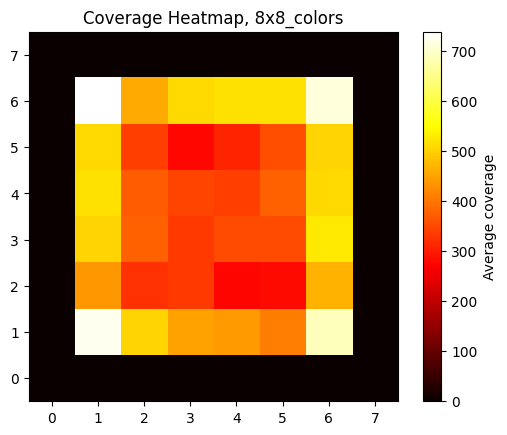

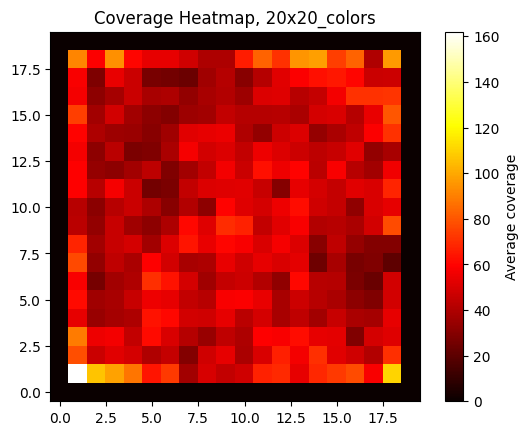

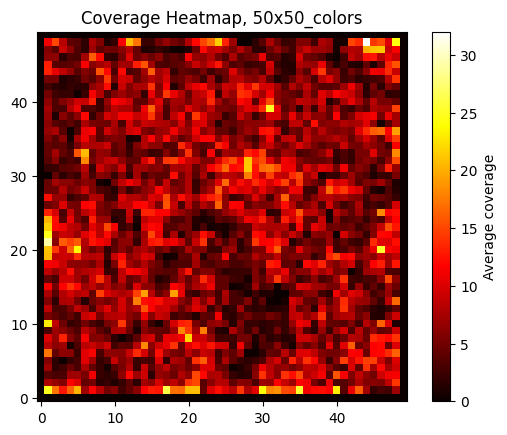

In [11]:
for c in range(len(map_files)):
    map_width, map_height = dims[c]
    seeds_data = np.zeros((len(seeds), map_width, map_height))
    for s, seed in enumerate(seeds):
        coords = np.array(loaded_data[c][seed][1])
        if coords.size > 0:
            np.add.at(seeds_data[s], (coords[:,0], coords[:,1]), 1)
    avg_cover = np.mean(seeds_data, axis=0)

    plt.imshow(avg_cover, cmap='hot', interpolation='nearest',vmin=0,vmax=800)
    plt.imshow(avg_cover, cmap='hot', interpolation='nearest')
    plt.gca().invert_yaxis()
    plt.colorbar(label='Average coverage')
    plt.title(f"Coverage Heatmap, {map_labels[c]}")
    plt.show()

#### View env

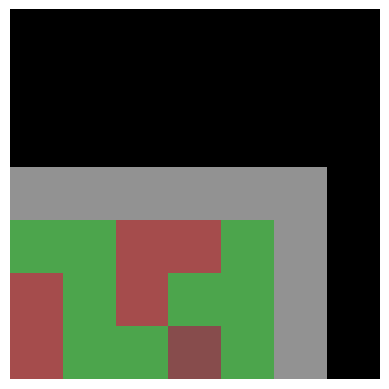

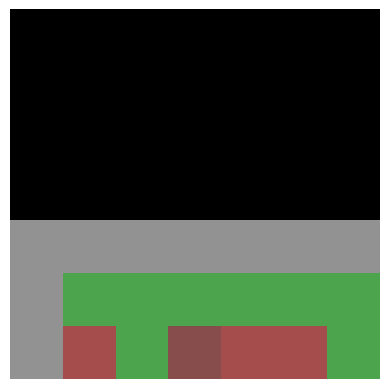

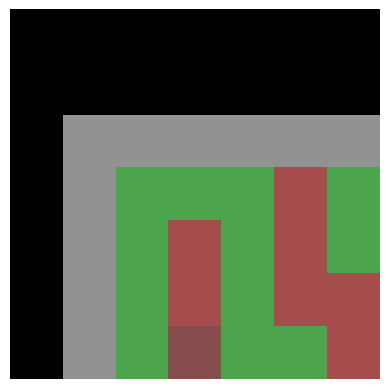

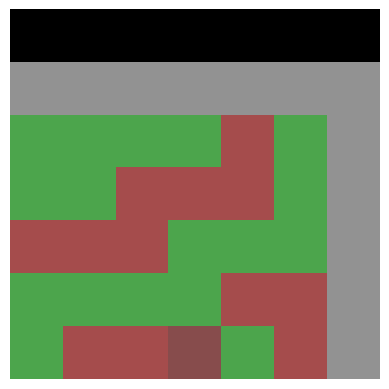

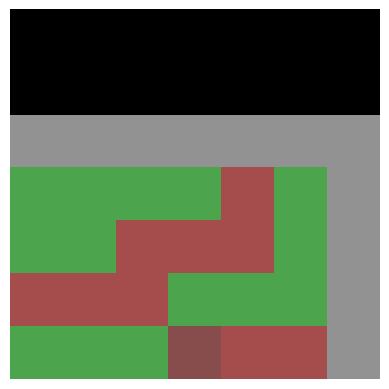

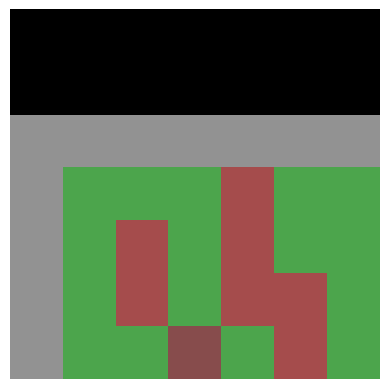

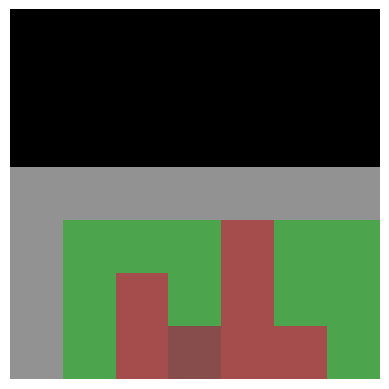

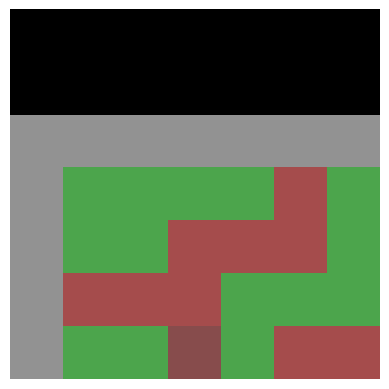

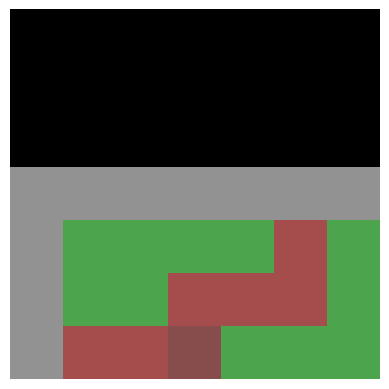

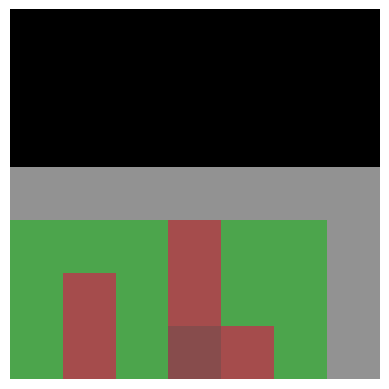

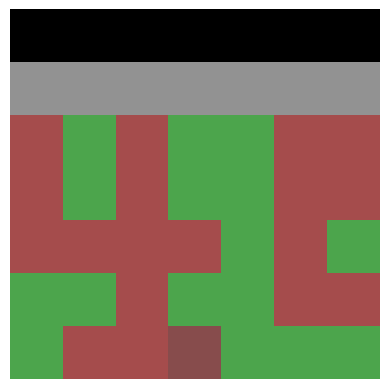

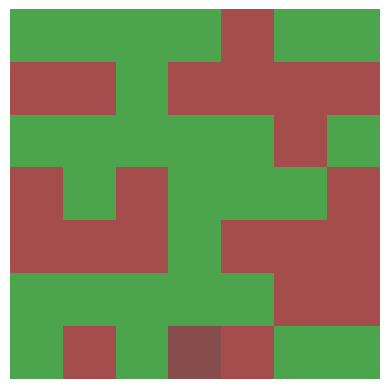

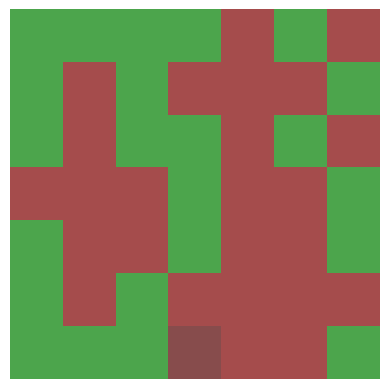

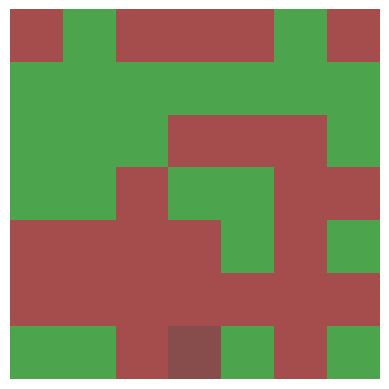

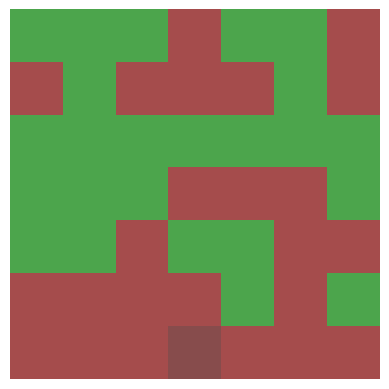

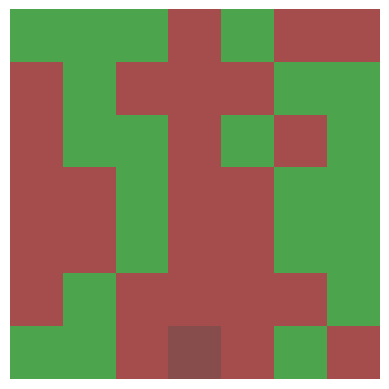

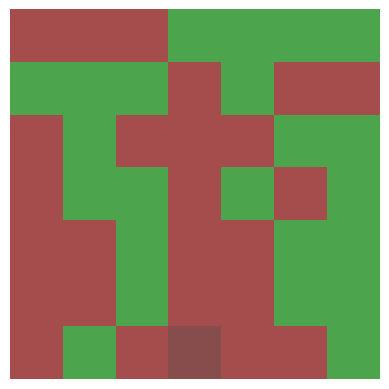

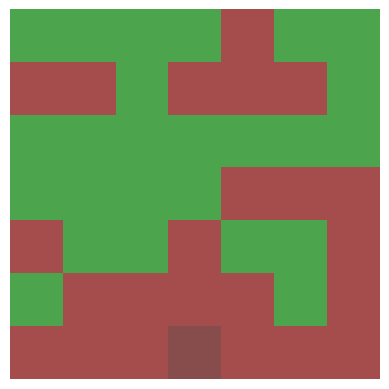

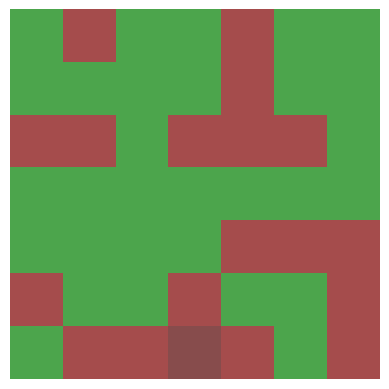

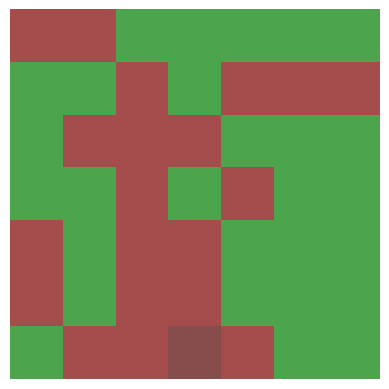

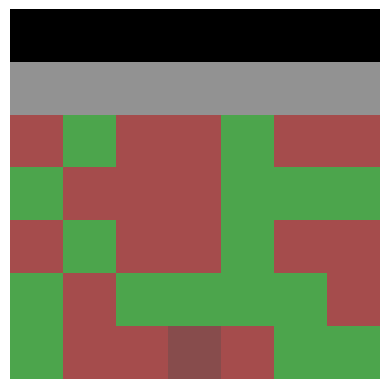

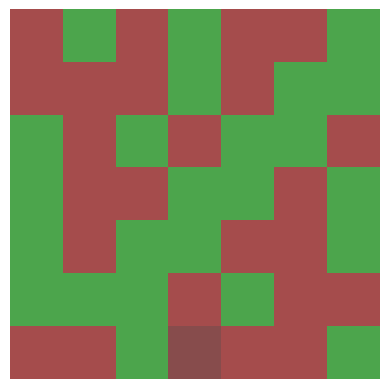

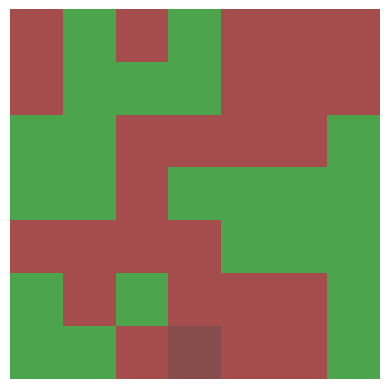

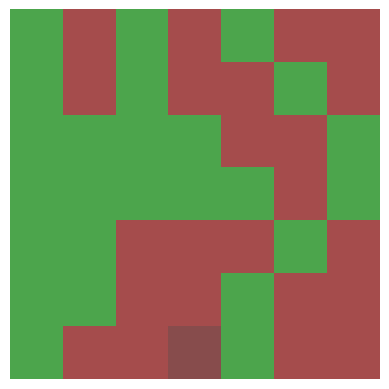

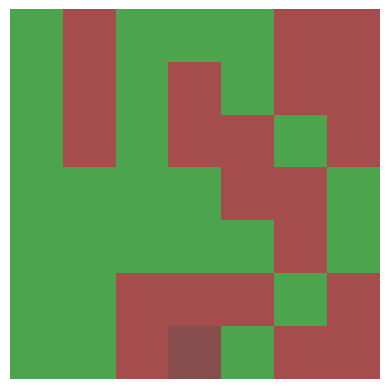

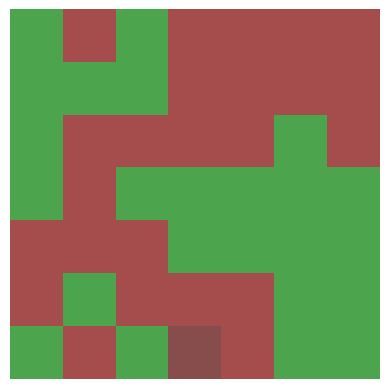

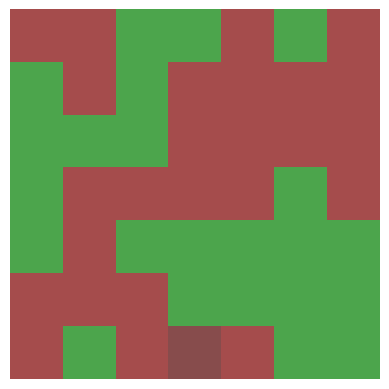

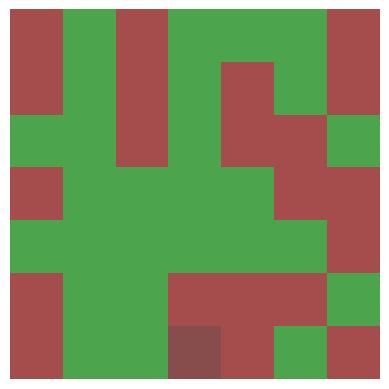

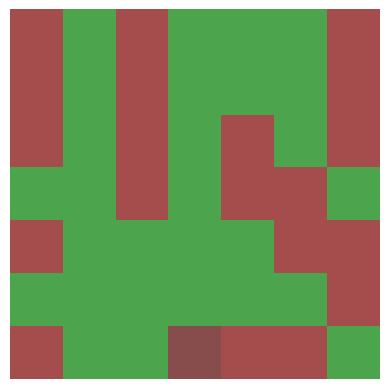

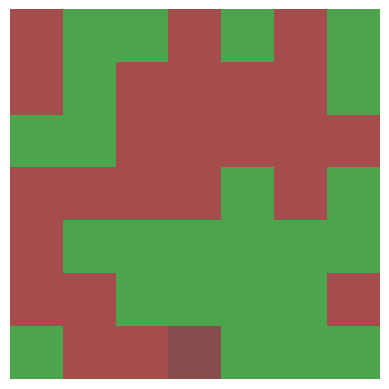

In [12]:
for c in range(len(map_labels)):
    ar = np.array(loaded_data[c][77243][0])[:,:-1]
    img = ar.reshape(-1,7, 7, 3).astype(np.uint8)

    for i in range(150,160):
        plt.imshow(img[i], interpolation='nearest')
        plt.axis('off') # Hide pixel coordinates
        plt.show()